# Auditoría de calidad y plausibilidad de fuentes ambientales — 2024

1. **Objetivo del notebook**

- Auditar el panel ERA5 y los GeoTIFF NDVI antes de su integración.
- Contrastar la plausibilidad climática con referencias externas.

2. **Decisiones metodológicas**

- Informar problemas sin corregir ni imputar las fuentes.
- Examinar NDVI a nivel de píxel dentro del área de estudio; la cobertura por celda se calcula en `01`.
- Usar CIREN e INIA sólo como referencias contextuales de otros periodos.

3. **Fuentes**

- `data/raw/environment/era5_weather_altitude_epiweek_2024_population.parquet`.
- `data/reference/climate/ciren_station_climatology.csv`.
- `data/reference/climate/inia_december_2021_stations.csv`.
- GeoTIFF NDVI externos definidos por `TESIS_NDVI_ROOT`.

4. **Productos**

- Tablas de auditoría en `data/diagnostics/source_exploration`, incluidos `ndvi_file_inventory.csv` y `source_quality_catalog.csv`.
- Figuras en `outputs/figures/source_exploration`.


## Configuración y rutas

Se centralizan rutas y parámetros. `RUN_FULL_RASTER_SCAN` controla la lectura global de los 104 GeoTIFF; los percentiles usan una muestra reproducible por bloque.


In [1]:
# Importación de bibliotecas necesarias
import os
import re
import sys
import warnings
from contextlib import ExitStack
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import rasterio
import seaborn as sns
from IPython.display import Markdown, display
from pyproj import CRS
from rasterio.features import geometry_mask

# Configuración de la raíz del proyecto y rutas de acceso (paths.py)
PROJECT_ROOT = Path.cwd().resolve() # Raíz del proyecto
while not (PROJECT_ROOT / "src").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").is_dir():
    raise FileNotFoundError("No se encontró la raíz del proyecto con una carpeta src.")
sys.path.append(str(PROJECT_ROOT))

# Importación de módulos personalizados desde la carpeta src
from src.paths import DATA_DIAGNOSTICS, FIGURES_DIR, RAW_CLIMATE, require_ndvi_external_dir
from src.epidemiological_calendar import (
    EPI_YEAR,
    N_EPIWEEKS,
    build_epidemiological_calendar,
)

# Configuración de advertencias y opciones de visualización
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

# Función para mostrar tablas con título y contexto
def show_table(title, context, frame, max_rows=None):
    displayed = frame.head(max_rows) if max_rows is not None else frame
    dimensions = f"{len(frame):,} filas × {frame.shape[1]} columnas"
    sample_note = (
        f" Se muestran las primeras {min(max_rows, len(frame)):,} filas."
        if max_rows is not None and len(frame) > max_rows
        else ""
    )
    display(
        Markdown(
            f"### {title}\n\n{context}\n\n"
            f"**Dimensiones:** {dimensions}.{sample_note}"
        )
    )
    display(displayed)

# Configuración de rutas de acceso a archivos de datos
ERA5_PATH = RAW_CLIMATE / "era5_weather_altitude_epiweek_2024_population.parquet"
CIREN_PATH = PROJECT_ROOT / "data" / "reference" / "climate" / "ciren_station_climatology.csv"
INIA_PATH = PROJECT_ROOT / "data" / "reference" / "climate" / "inia_december_2021_stations.csv"
NDVI_EXTERNAL_DIR = require_ndvi_external_dir()

# Creación de directorios para diagnósticos y figuras
DIAG_DIR = DATA_DIAGNOSTICS / "source_exploration"
FIG_DIR = FIGURES_DIR / "source_exploration"
DIAG_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Definición de "interruptores" para controlar la ejecución de análisis específicos
RUN_FULL_RASTER_SCAN = True # Ejecutar el análisis global de los píxeles
# -------------------------------------------------------------------------
# Definición de parámetros para el análisis
SAMPLES_PER_BLOCK = 200 # Tamaño de la muestra por bloque para percentiles
RANDOM_STATE = 42 # Semilla para reproducibilidad

# Imprimir información de rutas de acceso
print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Parquet ERA5: {ERA5_PATH}")
print(f"NDVI externo: {NDVI_EXTERNAL_DIR}")
print(f"Diagnósticos: {DIAG_DIR}")


Raíz del proyecto: C:\tesis_aedes_grilla_2024
Parquet ERA5: C:\tesis_aedes_grilla_2024\data\raw\environment\era5_weather_altitude_epiweek_2024_population.parquet
NDVI externo: D:\GeoTIFF NDVI
Diagnósticos: C:\tesis_aedes_grilla_2024\data\diagnostics\source_exploration


## Carga de fuentes y referencias

Se cargan ERA5, CIREN e INIA. GeoPandas conserva la geometría y su sistema de referencia de coordenadas (CRS).


In [2]:
# Verificar la existencia de los archivos requeridos
required_files = [ERA5_PATH, CIREN_PATH, INIA_PATH]
missing_files = [path for path in required_files if not path.is_file()]
if missing_files:
    raise FileNotFoundError(f"Faltan fuentes requeridas: {missing_files}")

# Cargar el Parquet ambiental ERA5 una sola vez y verificar su CRS.
era5 = gpd.read_parquet(ERA5_PATH)
# Este descriptor solo consulta el encabezado técnico del Parquet; no vuelve a cargar sus filas.
era5_parquet_descriptor = pq.ParquetFile(ERA5_PATH)
if era5.crs is None:
    raise ValueError("El Parquet ambiental no expone un CRS.")
source_crs = CRS.from_user_input(era5.crs)

# Cargar referencias externas
ciren = pd.read_csv(CIREN_PATH)
inia = pd.read_csv(INIA_PATH)  # Coordenadas y altitudes verificadas en las fichas oficiales DMC-SACLIM/RedINIA.
epi_calendar = build_epidemiological_calendar()

# Imprimir información de las fuentes cargadas
print(f"ERA5: {len(era5):,} filas × {era5.shape[1]} columnas")
print(f"CRS: {source_crs}")
print(f"CIREN: {len(ciren)} estaciones")
print(f"INIA: {len(inia)} estaciones o sectores")
show_table(
    "Vista inicial de la referencia climatológica CIREN",
    "Primeras filas de la tabla externa usada para contrastar órdenes de magnitud climáticos por estación y piso altitudinal. Corresponde a una referencia climatológica, construida a partir del cuadro 1 del informe 'Caracterización de Humedales Altoandinos para una gestión sustentable de las actividades productivas del sector norte del país' de CIREN, 2013. No representa el mismo periodo ni la misma escala espacial que ERA5 2024.\n Accede al informe: https://bibliotecadigital.ciren.cl/items/5b6bef43-ec8f-4cc4-b852-69073ec1d0ad ",
    ciren,
    max_rows=20,
)
show_table(
    "Vista inicial de la referencia INIA",
    "Primeras filas de las estaciones o sectores INIA usados como referencia para temperatura y humedad en diciembre de 2021. Corresponde a una referencia climatológica, construida a partir del informe 'Boletín Nacional de Análisis de Riesgos Agroclimáticos para las Principales Especies Frutales y Cultivos y la Ganadería' de INIA, publicado en enero de 2022. No representan el mismo periodo ni la misma escala espacial que ERA5 2024. \n Accede al informe: http://riesgoclimatico.inia.cl/public/boletines/eyJpdiI6IlNjN1ZVc05Qd2FmWDBPNUdHZjE1b0E9PSIsInZhbHVlIjoiZzlqSGRNYkpaRVNuMUFmSTl6YXR2dz09IiwibWFjIjoiYjBmY2NlNDg2NmNhODQzYmJjZGRlMTc2ZWFlYWI0NjU1MDg2ODMwM2ExMDliZTlmNjE1MmQ1MTg5OGEzZmM5YSJ9 ",
    inia,
    max_rows=20,
)
show_table(
    "Vista inicial del Parquet ambiental ERA5",
    "Muestra de la fuente previa a la incorporación de NDVI. Cada fila representa una combinación de grilla y semana epidemiológica, salvo las filas sin periodo que se diagnostican posteriormente.",
    era5,
    max_rows=5,
)


ERA5: 177,323 filas × 16 columnas
CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum": {"type": "GeodeticReferenceFrame", "name": "World Geodetic System 1984", "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east", "unit": "degree"}]}, "id": {"authority": "EPSG", "code": 4326}}
CIREN: 20 estaciones
INIA: 7 estaciones o sectores


### Vista inicial de la referencia climatológica CIREN

Primeras filas de la tabla externa usada para contrastar órdenes de magnitud climáticos por estación y piso altitudinal. Corresponde a una referencia climatológica, construida a partir del cuadro 1 del informe 'Caracterización de Humedales Altoandinos para una gestión sustentable de las actividades productivas del sector norte del país' de CIREN, 2013. No representa el mismo periodo ni la misma escala espacial que ERA5 2024.
 Accede al informe: https://bibliotecadigital.ciren.cl/items/5b6bef43-ec8f-4cc4-b852-69073ec1d0ad 

**Dimensiones:** 20 filas × 4 columnas.

,estacion,altitud_m,precipitacion_anual_media_mm,zona_altitud
0,Alcérreca,3990,214.3,Altiplano (≥3500 m)
1,Arica Oficina,20,1.1,Litoral y valles (<1000 m)
2,Azapa,365,0.8,Litoral y valles (<1000 m)
3,Caquena,4400,419.4,Altiplano (≥3500 m)
4,Central Chapiquiña,3350,167.9,Marginal de altura (2000–3499 m)
5,Chilcaya,4270,299.6,Altiplano (≥3500 m)
6,Chucuyo Retén,4400,343.3,Altiplano (≥3500 m)
7,Chungará Ajata,4585,384.7,Altiplano (≥3500 m)
8,Chungará Retén,4570,325.2,Altiplano (≥3500 m)
9,Codpa,1870,13.5,Desierto interior (1000–1999 m)


### Vista inicial de la referencia INIA

Primeras filas de las estaciones o sectores INIA usados como referencia para temperatura y humedad en diciembre de 2021. Corresponde a una referencia climatológica, construida a partir del informe 'Boletín Nacional de Análisis de Riesgos Agroclimáticos para las Principales Especies Frutales y Cultivos y la Ganadería' de INIA, publicado en enero de 2022. No representan el mismo periodo ni la misma escala espacial que ERA5 2024. 
 Accede al informe: http://riesgoclimatico.inia.cl/public/boletines/eyJpdiI6IlNjN1ZVc05Qd2FmWDBPNUdHZjE1b0E9PSIsInZhbHVlIjoiZzlqSGRNYkpaRVNuMUFmSTl6YXR2dz09IiwibWFjIjoiYjBmY2NlNDg2NmNhODQzYmJjZGRlMTc2ZWFlYWI0NjU1MDg2ODMwM2ExMDliZTlmNjE1MmQ1MTg5OGEzZmM5YSJ9 

**Dimensiones:** 7 filas × 19 columnas.

,estacion,nombre_en_informe,zona_inia,latitud,longitud,precision_ubicacion,codigo_dmc_saclim,fuente_coordenadas,altitud_m,fuente_altitud,pagina_pdf,zona_altitud,estado_verificacion,observaciones,temperatura_min_c,temperatura_media_c,temperatura_max_c,humedad_relativa_pct,inconsistencia_interna_fuente
0,Lluta Medio,Estación Lluta Medio,Valle costero (Arica),-18.452222,-70.067221,estación exacta,180034,https://climatologia.meteochile.gob.cl/applica...,532,https://climatologia.meteochile.gob.cl/applica...,Zona p. 2; descripción p. 3,Litoral y valles (<1000 m),verificado en fuente oficial externa,El informe la sitúa en el kilómetro 26 del val...,14.4,18.3,24.2,62.0,False
1,Azapa Medio,Estación Azapa Medio,Valle costero (Arica),-18.547777,-70.124721,estación exacta,180036,https://climatologia.meteochile.gob.cl/applica...,393,https://climatologia.meteochile.gob.cl/applica...,Zona p. 2; descripción pp. 3–4,Litoral y valles (<1000 m),verificado en fuente oficial externa,El informe la sitúa en el kilómetro 19 del val...,14.7,19.7,26.3,61.0,False
2,Pampa Concordia,Estación Pampa Concordia,Valle costero (Arica),-18.363055,-70.301944,estación exacta,180045,https://climatologia.meteochile.gob.cl/applica...,65,https://climatologia.meteochile.gob.cl/applica...,Zona p. 2; descripción p. 4,Litoral y valles (<1000 m),verificado en fuente oficial externa,El informe la sitúa en terrenos de INIA lote D...,17.8,20.1,22.9,66.0,False
3,Socoroma,Estación Socoroma,Precordillera (Putre),-18.263888,-69.607777,estación exacta,180030,https://climatologia.meteochile.gob.cl/applica...,3077,https://climatologia.meteochile.gob.cl/applica...,Zona p. 2; descripción p. 5,Marginal de altura (2000–3499 m),verificado en fuente oficial externa,La temperatura media transcrita del informe es...,12.2,9.8,18.9,51.0,True
4,Codpa,Estación Codpa,Valle interior de Camarones,-18.832499,-69.745555,estación exacta,180041,https://climatologia.meteochile.gob.cl/applica...,1870,https://climatologia.meteochile.gob.cl/applica...,Zona p. 2; descripción pp. 5–6,Desierto interior (1000–1999 m),verificado en fuente oficial externa,La altitud corresponde a la estación meteoroló...,12.3,18.3,25.3,50.0,False
5,Putre,Estación Putre,Precordillera (Putre),-18.196944,-69.553888,estación exacta,180029,https://climatologia.meteochile.gob.cl/applica...,3577,https://climatologia.meteochile.gob.cl/applica...,Zona p. 2; descripción pp. 6–7,Altiplano (≥3500 m),verificado en fuente oficial externa,Se seleccionó Putre INIA 180029 por pertenecer...,6.1,10.0,18.3,54.0,False
6,Visviri,Estación Visviri,Altiplano (General Lagos),-17.594721,-69.475277,estación exacta,170007,https://climatologia.meteochile.gob.cl/applica...,4122,https://climatologia.meteochile.gob.cl/applica...,Zona p. 2; descripción p. 7,Altiplano (≥3500 m),verificado en fuente oficial externa,Se seleccionó Visviri INIA 170007 por pertenec...,1.5,7.6,16.4,57.0,False


### Vista inicial del Parquet ambiental ERA5

Muestra de la fuente previa a la incorporación de NDVI. Cada fila representa una combinación de grilla y semana epidemiológica, salvo las filas sin periodo que se diagnostican posteriormente.

**Dimensiones:** 177,323 filas × 16 columnas. Se muestran las primeras 5 filas.

,grid_id,year,epiweek,tmean_c,tmin_c,tmax_c,alt_min,alt_mean,alt_max,rh_mean,rh_min,rh_max,tp_sum,geometry,koppen_fin,population
0,0,2024.0,1.0,21.209301,19.992899,22.276896,25.0,33.596774,43.0,74.356583,71.468781,76.885185,0.016606,"MULTIPOLYGON (((-70.36661 -18.33815, -70.36389...",BWh,0.0
1,0,2024.0,2.0,22.054096,21.573660,22.765982,25.0,33.596774,43.0,73.982315,71.317276,76.284805,0.011030,"MULTIPOLYGON (((-70.36661 -18.33815, -70.36389...",BWh,0.0
2,0,2024.0,3.0,22.568083,22.038534,23.052988,25.0,33.596774,43.0,75.665398,72.660240,78.163437,0.068585,"MULTIPOLYGON (((-70.36661 -18.33815, -70.36389...",BWh,0.0
3,0,2024.0,4.0,23.774378,23.398520,24.111084,25.0,33.596774,43.0,72.535446,70.525070,74.601913,0.008243,"MULTIPOLYGON (((-70.36661 -18.33815, -70.36389...",BWh,0.0
4,0,2024.0,5.0,22.861515,22.499634,23.158884,25.0,33.596774,43.0,73.460915,72.232567,74.605240,0.005395,"MULTIPOLYGON (((-70.36661 -18.33815, -70.36389...",BWh,0.0


## Inventario, esquema, metadatos y nulos

Se resume cada variable mediante su tipo Arrow, nulabilidad declarada, nulos observados, metadatos y unidad documentada. La unidad no se infiere del nombre.


### Inventario del archivo ambiental ERA5

Resume ubicación, tamaño, dimensiones, CRS, grupos internos de Parquet y claves generales de metadatos del archivo fuente.

**Dimensiones:** 1 filas × 8 columnas.

,fuente,ruta,bytes,filas,columnas,crs,row_groups,metadatos_archivo
0,ERA5 ambiental agregado,C:\tesis_aedes_grilla_2024\data\raw\environmen...,2741696,177323,16,EPSG:4326,1,"[ARROW:schema, geo, pandas]"


### Esquema, metadatos y nulos de las variables del Parquet

Reúne la estructura declarada y la completitud observada. 'Permite nulos' es una propiedad del esquema Arrow; 'nulos observados' y 'nulos pct' se calculan sobre todas las filas del archivo; 'unidad documentada' considera únicamente metadatos explícitos del campo.

**Dimensiones:** 16 filas × 7 columnas.

,variable,tipo,permite_nulos,nulos_observados,nulos_pct,tiene_metadatos,unidad_documentada
0,grid_id,entero,Sí,0,0.0000,No,No
1,year,decimal,Sí,55,0.0310,No,No
2,epiweek,decimal,Sí,55,0.0310,No,No
3,tmean_c,decimal,Sí,55,0.0310,No,No
4,tmin_c,decimal,Sí,55,0.0310,No,No
5,tmax_c,decimal,Sí,55,0.0310,No,No
6,alt_min,decimal,Sí,262,0.1478,No,No
7,alt_mean,decimal,Sí,262,0.1478,No,No
8,alt_max,decimal,Sí,262,0.1478,No,No
9,rh_mean,decimal,Sí,55,0.0310,No,No


### Distribución de los nulos observados

El gráfico izquierdo usa todas las filas del archivo y coincide con los conteos de la tabla anterior. El derecho considera únicamente filas con `grid_id`, `year` y `epiweek` completos, y muestra el porcentaje de filas con algún nulo ambiental en cada semana.

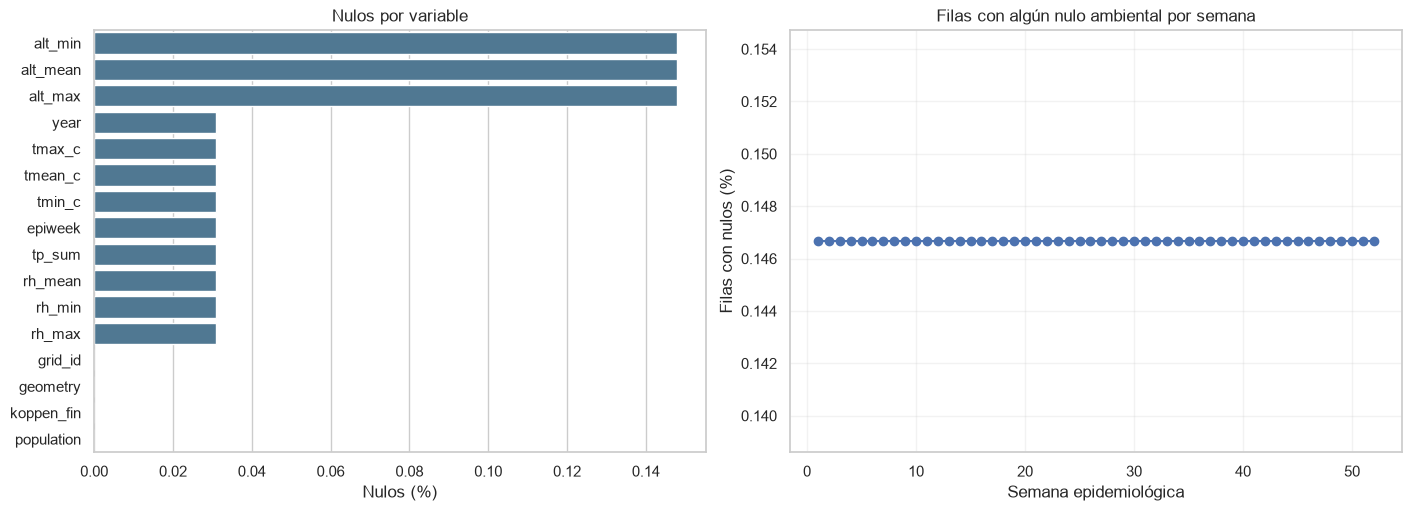

### Distribución espacial de los nulos ambientales

El mapa muestra cuántas semanas con periodo completo presentan al menos un nulo entre las variables ambientales examinadas para cada `grid_id`.

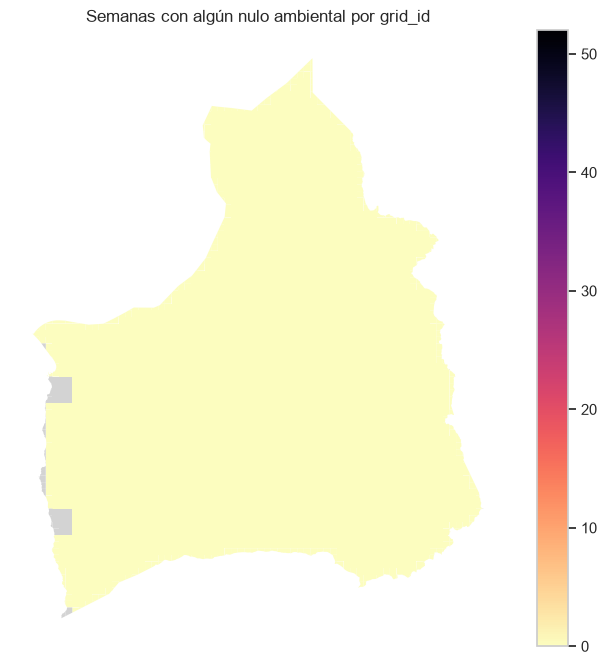

In [3]:
# Diccionario para mapear tipos de datos de Arrow a nombres más amigables en español
FRIENDLY_ARROW_TYPES = {
    "int64": "entero",
    "double": "decimal",
    "string": "texto",
    "binary": "binario",
}

# Construcción de un DataFrame con información del esquema, metadatos y nulos observados
schema_rows = []
field_metadata_by_variable = {}
for field in era5_parquet_descriptor.schema_arrow:
    field_metadata = {
        key.decode(errors="replace"): value.decode(errors="replace")
        for key, value in (field.metadata or {}).items()
    }
    field_metadata_by_variable[field.name] = field_metadata
    unit_values = [
        value
        for key, value in field_metadata.items()
        if "unit" in key.casefold() or "unidad" in key.casefold()
    ]
    is_geometry = field.name == "geometry"
    schema_rows.append(
        {
            "variable": field.name,
            "tipo": (
                "geometría WKB"
                if is_geometry
                else FRIENDLY_ARROW_TYPES.get(str(field.type), str(field.type))
            ),
            "permite_nulos": "Sí" if field.nullable else "No",
            "tiene_metadatos": "Sí" if field_metadata else "No",
            "unidad_documentada": (
                "No aplica"
                if is_geometry
                else ", ".join(unit_values) if unit_values else "No"
            ),
        }
    )
schema_report = pd.DataFrame(schema_rows)
null_counts = era5.isna().sum()
schema_report["nulos_observados"] = (
    schema_report["variable"].map(null_counts).fillna(0).astype(int)
)
schema_report["nulos_pct"] = (
    100 * schema_report["nulos_observados"] / len(era5)
).round(4)
schema_report = schema_report[
    [
        "variable", "tipo", "permite_nulos",
        "nulos_observados", "nulos_pct",
        "tiene_metadatos", "unidad_documentada",
    ]
]

environment_columns = [
    column for column in [
        "tmean_c", "tmin_c", "tmax_c",
        "rh_mean", "rh_min", "rh_max",
        "tp_sum", "alt_min", "alt_mean", "alt_max",
        "koppen_fin", "population",
    ]
    if column in era5.columns
]

source_inventory = pd.DataFrame(
    [
        {
            "fuente": "ERA5 ambiental agregado",
            "ruta": str(ERA5_PATH),
            "bytes": ERA5_PATH.stat().st_size,
            "filas": len(era5),
            "columnas": era5.shape[1],
            "crs": source_crs.to_string(),
            "row_groups": era5_parquet_descriptor.num_row_groups,
            "metadatos_archivo": sorted(
                key.decode(errors="replace")
                for key in (era5_parquet_descriptor.metadata.metadata or {})
            ),
        }
    ]
)

tp_metadata = field_metadata_by_variable.get("tp_sum", {})
tp_unit_documented = bool(
    schema_report.loc[
        schema_report["variable"].eq("tp_sum"),
        "unidad_documentada",
    ].ne("No").iloc[0]
)

source_inventory.to_csv(DIAG_DIR / "era5_source_inventory.csv", index=False)
schema_report.to_csv(DIAG_DIR / "era5_schema_metadata_and_nulls.csv", index=False)

show_table(
    "Inventario del archivo ambiental ERA5",
    "Resume ubicación, tamaño, dimensiones, CRS, grupos internos de Parquet y claves generales de metadatos del archivo fuente.",
    source_inventory,
)
show_table(
    "Esquema, metadatos y nulos de las variables del Parquet",
    "Reúne la estructura declarada y la completitud observada. 'Permite nulos' es una propiedad del esquema Arrow; 'nulos observados' y 'nulos pct' se calculan sobre todas las filas del archivo; 'unidad documentada' considera únicamente metadatos explícitos del campo.",
    schema_report,
)

# Localización temporal y espacial de los nulos ambientales.
null_key_columns = ["grid_id", "year", "epiweek"]
complete_key_mask = era5[null_key_columns].notna().all(axis=1)
null_panel = era5.loc[complete_key_mask].copy()
null_flags = null_panel[environment_columns].isna()

nulls_by_week = (
    null_panel.assign(fila_con_nulo=null_flags.any(axis=1))
    .groupby("epiweek", as_index=False)
    .agg(
        filas=("grid_id", "size"),
        filas_con_nulo=("fila_con_nulo", "sum"),
        grid_id=("grid_id", "nunique"),
    )
)
nulls_by_week["filas_con_nulo_pct"] = (
    100 * nulls_by_week["filas_con_nulo"] / nulls_by_week["filas"]
)
nulls_by_grid = (
    null_panel.assign(fila_con_nulo=null_flags.any(axis=1))
    .groupby("grid_id", as_index=False)
    .agg(
        semanas=("epiweek", "nunique"),
        semanas_con_nulo=("fila_con_nulo", "sum"),
    )
)
nulls_by_grid["semanas_con_nulo_pct"] = (
    100 * nulls_by_grid["semanas_con_nulo"] / nulls_by_grid["semanas"]
)
nulls_by_week.to_csv(DIAG_DIR / "era5_nulls_by_week.csv", index=False)
nulls_by_grid.to_csv(DIAG_DIR / "era5_nulls_by_grid.csv", index=False)

display(
    Markdown(
        "### Distribución de los nulos observados\n\n"
        "El gráfico izquierdo usa todas las filas del archivo y coincide con los conteos de la tabla anterior. "
        "El derecho considera únicamente filas con `grid_id`, `year` y `epiweek` completos, "
        "y muestra el porcentaje de filas con algún nulo ambiental en cada semana."
    )
)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
nulls_for_plot = schema_report.sort_values("nulos_pct", ascending=False)
sns.barplot(
    data=nulls_for_plot,
    y="variable",
    x="nulos_pct",
    color="#457b9d",
    ax=axes[0],
)
axes[0].set(title="Nulos por variable", xlabel="Nulos (%)", ylabel="")
axes[1].plot(
    nulls_by_week["epiweek"],
    nulls_by_week["filas_con_nulo_pct"],
    marker="o",
)
axes[1].set(
    title="Filas con algún nulo ambiental por semana",
    xlabel="Semana epidemiológica",
    ylabel="Filas con nulos (%)",
)
axes[1].grid(alpha=0.25)
fig.savefig(FIG_DIR / "era5_nulls_summary.png", dpi=180, bbox_inches="tight")
plt.show()

display(
    Markdown(
        "### Distribución espacial de los nulos ambientales\n\n"
        "El mapa muestra cuántas semanas con periodo completo presentan al menos un nulo "
        "entre las variables ambientales examinadas para cada `grid_id`."
    )
)
null_map_geometry = gpd.GeoDataFrame(
    era5.loc[~era5["grid_id"].duplicated(), ["grid_id", "geometry"]].copy(),
    geometry="geometry",
    crs=era5.crs,
)
grid_null_map = null_map_geometry.merge(nulls_by_grid, on="grid_id", how="left")
fig, ax = plt.subplots(figsize=(8, 8))
grid_null_map.plot(
    column="semanas_con_nulo",
    cmap="magma_r",
    legend=True,
    linewidth=0,
    missing_kwds={"color": "lightgrey"},
    ax=ax,
)
ax.set_title("Semanas con algún nulo ambiental por grid_id")
ax.axis("off")
fig.savefig(FIG_DIR / "era5_nulls_by_grid.png", dpi=180, bbox_inches="tight")
plt.show()


## Integridad espacial y temporal del panel ERA5

Se revisan llaves nulas, duplicados, cobertura semanal y geometrías, sin modificar las filas.


In [4]:
# Evaluación de la integridad estructural del panel ERA5
# | or & and ~ complemento
key_columns = ["grid_id", "year", "epiweek"]
missing_grid_id = era5["grid_id"].isna()
missing_year = era5["year"].isna()
missing_epiweek = era5["epiweek"].isna()
missing_period = missing_year | missing_epiweek 
missing_both_period_fields = missing_year & missing_epiweek
missing_only_one_period_field = missing_period & ~missing_both_period_fields
keyed = era5.loc[~(missing_grid_id | missing_period)].copy() # DataFrame con filas y columnas completas 
keyed["year"] = keyed["year"].astype(int)
keyed["epiweek"] = keyed["epiweek"].astype(int)

duplicate_panel_keys = keyed.duplicated(key_columns, keep=False)
weeks_per_grid = keyed.groupby("grid_id")["epiweek"].nunique()
unexpected_year_week = ~(
    keyed["year"].eq(EPI_YEAR)
    & keyed["epiweek"].between(1, N_EPIWEEKS)
)

# Evaluación de la consistencia geométrica de los grid_id
geometry_wkb = era5.geometry.to_wkb()
geometry_counts = geometry_wkb.groupby(era5["grid_id"]).nunique(dropna=True)
grid_geometry = gpd.GeoDataFrame(
    era5.loc[~era5["grid_id"].duplicated(), ["grid_id", "geometry"]].copy(),
    geometry="geometry",
    crs=era5.crs,
).sort_values("grid_id").reset_index(drop=True)

# Construcción de un informe estructural con los controles y resultados
structural_report = pd.DataFrame(
    [
        {"control": "filas sin grid_id", "cantidad": int(missing_grid_id.sum()), "unidad": "filas", "detalle": "No es posible asignarlas a una celda."},
        {"control": "filas sin year", "cantidad": int(missing_year.sum()), "unidad": "filas", "detalle": "Conteo descriptivo de ausencias en year."},
        {"control": "filas sin epiweek", "cantidad": int(missing_epiweek.sum()), "unidad": "filas", "detalle": "Conteo descriptivo de ausencias en epiweek."},
        {"control": "filas sin periodo completo", "cantidad": int(missing_period.sum()), "unidad": "filas", "detalle": "Falta year, epiweek o ambos; incluye las filas sin periodo observadas en la fuente."},
        {"control": "combinaciones grid_id–year–epiweek duplicadas", "cantidad": int(duplicate_panel_keys.sum()), "unidad": "filas", "detalle": "Cuenta todas las filas que participan en una llave repetida."},
        {"control": "filas fuera de 2024 o de las semanas 1–52", "cantidad": int(unexpected_year_week.sum()), "unidad": "filas", "detalle": "Se evalúa solo donde grid_id, year y epiweek están presentes."},
        {"control": "grid_id con menos o más de 52 semanas únicas", "cantidad": int(weeks_per_grid.ne(N_EPIWEEKS).sum()), "unidad": "grid_id", "detalle": "Resume la completitud temporal del panel 2024."},
        {"control": "grid_id asociados a más de una geometría", "cantidad": int(geometry_counts.gt(1).sum()), "unidad": "grid_id", "detalle": "Un mismo identificador espacial debería conservar su geometría."},
        {"control": "grid_id con geometría representativa nula", "cantidad": int(grid_geometry.geometry.isna().sum()), "unidad": "grid_id", "detalle": "Se revisa una geometría representativa por grid_id."},
        {"control": "grid_id con geometría representativa vacía", "cantidad": int(grid_geometry.geometry.is_empty.sum()), "unidad": "grid_id", "detalle": "Una geometría vacía no delimita superficie."},
        {"control": "grid_id con geometría representativa inválida", "cantidad": int((~grid_geometry.geometry.isna() & ~grid_geometry.geometry.is_valid).sum()), "unidad": "grid_id", "detalle": "La validez se evalúa según las reglas geométricas de GeoPandas/Shapely; los nulos se cuentan por separado."},
    ]
)
structural_report["resultado"] = np.where(
    structural_report["cantidad"].eq(0), "no observado", "observado"
)
structural_report.to_csv(DIAG_DIR / "era5_structural_quality.csv", index=False)

show_table(
    "Integridad espacial y temporal del panel ERA5",
    "Describe la identificación de las filas, la unicidad de las combinaciones celda–semana, la cobertura de 52 semanas y la consistencia geométrica. 'Observado' indica que existen casos; su interpretación depende del indicador y no significa que el notebook los haya corregido.",
    structural_report,
)
print(f"Filas con llaves completas: {len(keyed):,}")
print(f"grid_id únicos: {keyed['grid_id'].nunique():,}")


### Integridad espacial y temporal del panel ERA5

Describe la identificación de las filas, la unicidad de las combinaciones celda–semana, la cobertura de 52 semanas y la consistencia geométrica. 'Observado' indica que existen casos; su interpretación depende del indicador y no significa que el notebook los haya corregido.

**Dimensiones:** 11 filas × 5 columnas.

,control,cantidad,unidad,detalle,resultado
0,filas sin grid_id,0,filas,No es posible asignarlas a una celda.,no observado
1,filas sin year,55,filas,Conteo descriptivo de ausencias en year.,observado
2,filas sin epiweek,55,filas,Conteo descriptivo de ausencias en epiweek.,observado
3,filas sin periodo completo,55,filas,"Falta year, epiweek o ambos; incluye las filas...",observado
4,combinaciones grid_id–year–epiweek duplicadas,0,filas,Cuenta todas las filas que participan en una l...,no observado
5,filas fuera de 2024 o de las semanas 1–52,0,filas,"Se evalúa solo donde grid_id, year y epiweek e...",no observado
6,grid_id con menos o más de 52 semanas únicas,0,grid_id,Resume la completitud temporal del panel 2024.,no observado
7,grid_id asociados a más de una geometría,0,grid_id,Un mismo identificador espacial debería conser...,no observado
8,grid_id con geometría representativa nula,0,grid_id,Se revisa una geometría representativa por gri...,no observado
9,grid_id con geometría representativa vacía,0,grid_id,Una geometría vacía no delimita superficie.,no observado


Filas con llaves completas: 177,268
grid_id únicos: 3,409


## Consistencia física y distribuciones de ERA5

Se revisan relaciones físicas básicas y distribuciones numéricas. Estos controles no reemplazan la validación de la fuente original.


In [5]:
# Evaluación de la consistencia física interna de las variables ambientales
def physical_check(name, evaluated_mask, failure_mask):
    evaluated_mask = pd.Series(evaluated_mask, index=keyed.index).fillna(False) # máscara de filas evaluables
    failure_mask = pd.Series(failure_mask, index=keyed.index).fillna(False) & evaluated_mask # máscara de filas fallidas
    evaluated = int(evaluated_mask.sum())
    failed = int(failure_mask.sum())
    return {
        "control": name,
        "filas_evaluadas": evaluated,
        "filas_fallidas": failed,
        "porcentaje_fallido": 100 * failed / evaluated if evaluated else np.nan,
        "estado": "válido" if failed == 0 and evaluated else ("no evaluable" if not evaluated else "crítico"),
    }

# Construcción de máscaras para controles físicos
# keyed es un DataFrame que contiene solo las filas con llaves completas (grid_id, year, epiweek) (keyed = era5.loc[  ~(missing_grid_id | missing_period)].copy())
temperature_complete = keyed[["tmin_c", "tmean_c", "tmax_c"]].notna().all(axis=1)
humidity_complete = keyed[["rh_min", "rh_mean", "rh_max"]].notna().all(axis=1)
altitude_complete = keyed[["alt_min", "alt_mean", "alt_max"]].notna().all(axis=1)
precipitation_observed = keyed["tp_sum"].notna()

# Construcción de un DataFrame con los resultados de los controles físicos
physical_checks = pd.DataFrame(
    [
        physical_check(
            "tmin_c ≤ tmean_c ≤ tmax_c",
            temperature_complete,
            (keyed["tmin_c"] > keyed["tmean_c"]) | (keyed["tmean_c"] > keyed["tmax_c"]),
        ),
        physical_check(
            "rh_min ≤ rh_mean ≤ rh_max",
            humidity_complete,
            (keyed["rh_min"] > keyed["rh_mean"]) | (keyed["rh_mean"] > keyed["rh_max"]),
        ),
        physical_check(
            "humedad relativa dentro de 0–100 %",
            humidity_complete,
            keyed[["rh_min", "rh_mean", "rh_max"]].lt(0).any(axis=1)
            | keyed[["rh_min", "rh_mean", "rh_max"]].gt(100).any(axis=1),
        ),
        physical_check(
            "tp_sum no negativa",
            precipitation_observed,
            keyed["tp_sum"].lt(0),
        ),
        physical_check(
            "alt_min ≤ alt_mean ≤ alt_max",
            altitude_complete,
            (keyed["alt_min"] > keyed["alt_mean"]) | (keyed["alt_mean"] > keyed["alt_max"]),
        ),
    ]
)

# Construcción de un informe de distribución para las variables ambientales numéricas
numeric_environment = [
    column for column in environment_columns 
]

# Construcción de un DataFrame con estadísticas descriptivas y percentiles para las variables numéricas
distribution_report = (
    keyed[numeric_environment]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]) #describe = genera estadísticos descriptivos de las columnas numéricas, incluyendo percentiles especificados
    .T
    .reset_index(names="variable")
)

physical_checks.to_csv(DIAG_DIR / "era5_physical_consistency.csv", index=False)
distribution_report.to_csv(DIAG_DIR / "era5_numeric_distributions.csv", index=False)

show_table(
    "Controles de consistencia física interna",
    "Evalúa relaciones como mínima ≤ media ≤ máxima y rangos físicos básicos. Una falla indica inconsistencia interna; superar el control no demuestra por sí solo validez externa.",
    physical_checks,
)
show_table(
    "Distribución de las variables ambientales numéricas",
    "Estadísticos descriptivos sobre filas con llaves completas. Los percentiles resumen observaciones grilla–semana y no están ponderados por población.",
    distribution_report,
)


### Controles de consistencia física interna

Evalúa relaciones como mínima ≤ media ≤ máxima y rangos físicos básicos. Una falla indica inconsistencia interna; superar el control no demuestra por sí solo validez externa.

**Dimensiones:** 5 filas × 5 columnas.

,control,filas_evaluadas,filas_fallidas,porcentaje_fallido,estado
0,tmin_c ≤ tmean_c ≤ tmax_c,177268,0,0.0,válido
1,rh_min ≤ rh_mean ≤ rh_max,177268,0,0.0,válido
2,humedad relativa dentro de 0–100 %,177268,0,0.0,válido
3,tp_sum no negativa,177268,0,0.0,válido
4,alt_min ≤ alt_mean ≤ alt_max,177008,0,0.0,válido


### Distribución de las variables ambientales numéricas

Estadísticos descriptivos sobre filas con llaves completas. Los percentiles resumen observaciones grilla–semana y no están ponderados por población.

**Dimensiones:** 11 filas × 13 columnas.

,variable,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
0,tmean_c,177268.0,11.038737,5.822546,-1.746113,0.928593,3.383251,6.218760,9.313034,16.652884,20.484972,22.579554,25.018829
1,tmin_c,177268.0,9.940885,6.050998,-3.841359,-0.755585,1.635913,5.048319,8.276825,15.634552,19.777212,21.962992,24.110687
2,tmax_c,177268.0,12.074569,5.691751,-0.956899,2.561412,4.571296,7.378276,10.352783,17.635132,21.237772,23.283539,25.648270
3,rh_mean,177268.0,49.881295,24.076192,7.646102,10.161090,13.165156,26.573385,50.857849,71.906166,84.996391,88.706245,94.644302
4,rh_min,177268.0,41.232132,24.624884,1.957023,3.404726,6.590209,17.767010,39.107519,63.596397,80.024678,85.777525,94.046936
5,rh_max,177268.0,59.186125,23.727963,12.055956,15.143582,21.841174,35.586426,62.197010,80.756493,91.106186,93.730225,97.602287
6,tp_sum,177268.0,0.093241,0.176469,0.000001,0.000016,0.000031,0.000118,0.005824,0.099094,0.460514,0.828460,1.357602
7,alt_min,177008.0,2954.852526,1513.331694,-3.000000,20.000000,383.000000,1418.750000,3578.000000,4260.000000,4623.000000,4931.000000,5612.000000
8,alt_mean,177008.0,3119.304912,1495.858815,5.666667,135.361538,600.590769,1618.785205,3726.032853,4350.832548,4807.258462,5178.913846,6019.342412
9,alt_max,177008.0,3292.184489,1517.169203,10.000000,280.000000,730.000000,1785.000000,3895.500000,4496.750000,5099.000000,5589.000000,6313.000000


## Pisos altitudinales y referencias externas

Se comparan ERA5 e INIA con cuatro intervalos operativos: litoral y valles (<1000 m), desierto interior (1000–1999 m), marginal de altura (2000–3499 m) y altiplano (≥3500 m). ERA5 usa `alt_mean`; INIA usa la altitud verificada de cada estación.

La comparación es contextual: ERA5 corresponde a diciembre de 2024 e INIA a diciembre de 2021. Socoroma se identifica como dato inconsistente porque su media informada es menor que su mínima.


### Clima ERA5 2024 por piso altitudinal operativo

Resume todas las observaciones grilla–semana clasificables mediante alt_mean. Los pisos son categorías analíticas del estudio; las medias y percentiles no están ponderados por población.

**Dimensiones:** 4 filas × 9 columnas.

,zona_altitud,grid_id,tmean_c_media,tmean_c_p05,tmean_c_p95,rh_mean_media,rh_mean_p05,rh_mean_p95,alt_mean
0,Litoral y valles (<1000 m),475,18.665470,15.116895,22.799618,69.299206,48.497704,83.734932,644.284652
1,Desierto interior (1000–1999 m),547,18.128448,15.284674,21.364222,54.067462,23.010559,79.417542,1444.413639
2,Marginal de altura (2000–3499 m),554,13.019543,8.828275,17.248596,47.279971,12.712636,86.303551,2893.532424
3,Altiplano (≥3500 m),1828,6.346917,2.460734,10.057165,44.392129,12.009613,85.288033,4332.039108


### ERA5 en semanas con punto medio en diciembre de 2024

Resumen construido exclusivamente para un contraste estacional aproximado con INIA. Incluye semanas epidemiológicas cuyo miércoles cae en diciembre; tmin_c y tmax_c son medias de los valores semanales, no extremos absolutos del mes.

**Dimensiones:** 4 filas × 6 columnas.

,zona_altitud,semanas,tmin_c,tmean_c,tmax_c,rh_mean
0,Litoral y valles (<1000 m),4,18.784823,19.388974,20.062260,70.015237
1,Desierto interior (1000–1999 m),4,17.662381,18.381462,19.275745,61.922323
2,Marginal de altura (2000–3499 m),4,12.645392,13.510865,14.241050,57.634778
3,Altiplano (≥3500 m),4,6.672060,7.559328,8.349778,49.181855


### Referencia INIA para diciembre de 2021

Cada estación conserva la zona territorial del informe y muestra, por separado, la zona altitudinal derivada de su altitud oficial DMC-SACLIM. Socoroma está marcado por una inconsistencia mínima–media en la fuente transcrita.

**Dimensiones:** 7 filas × 8 columnas.

,estacion,zona_inia,codigo_dmc_saclim,altitud_m,zona_altitud,temperatura_media_c,humedad_relativa_pct,inconsistencia_interna_fuente
0,Lluta Medio,Valle costero (Arica),180034,532,Litoral y valles (<1000 m),18.3,62.0,False
1,Azapa Medio,Valle costero (Arica),180036,393,Litoral y valles (<1000 m),19.7,61.0,False
2,Pampa Concordia,Valle costero (Arica),180045,65,Litoral y valles (<1000 m),20.1,66.0,False
3,Socoroma,Precordillera (Putre),180030,3077,Marginal de altura (2000–3499 m),9.8,51.0,True
4,Codpa,Valle interior de Camarones,180041,1870,Desierto interior (1000–1999 m),18.3,50.0,False
5,Putre,Precordillera (Putre),180029,3577,Altiplano (≥3500 m),10.0,54.0,False
6,Visviri,Altiplano (General Lagos),170007,4122,Altiplano (≥3500 m),7.6,57.0,False


### Referencia INIA resumida por piso altitudinal

Promedios usados en los gráficos comparativos. Se distinguen las temperaturas informadas, las válidas y las inconsistentes. La media de Socoroma se conserva en el gráfico, pero se identifica visualmente como inconsistente.

**Dimensiones:** 4 filas × 9 columnas.

,zona_altitud,estaciones_inia,estaciones_temperatura_informadas,estaciones_temperatura_validas,estaciones_temperatura_inconsistentes,estaciones_humedad_validas,tmean_c,rh_mean,temperatura_inconsistente
0,Litoral y valles (<1000 m),3,3,3,0,3,19.366667,63.0,False
1,Desierto interior (1000–1999 m),1,1,1,0,1,18.300000,50.0,False
2,Marginal de altura (2000–3499 m),1,1,0,1,1,9.800000,51.0,True
3,Altiplano (≥3500 m),2,2,2,0,2,8.800000,55.5,False


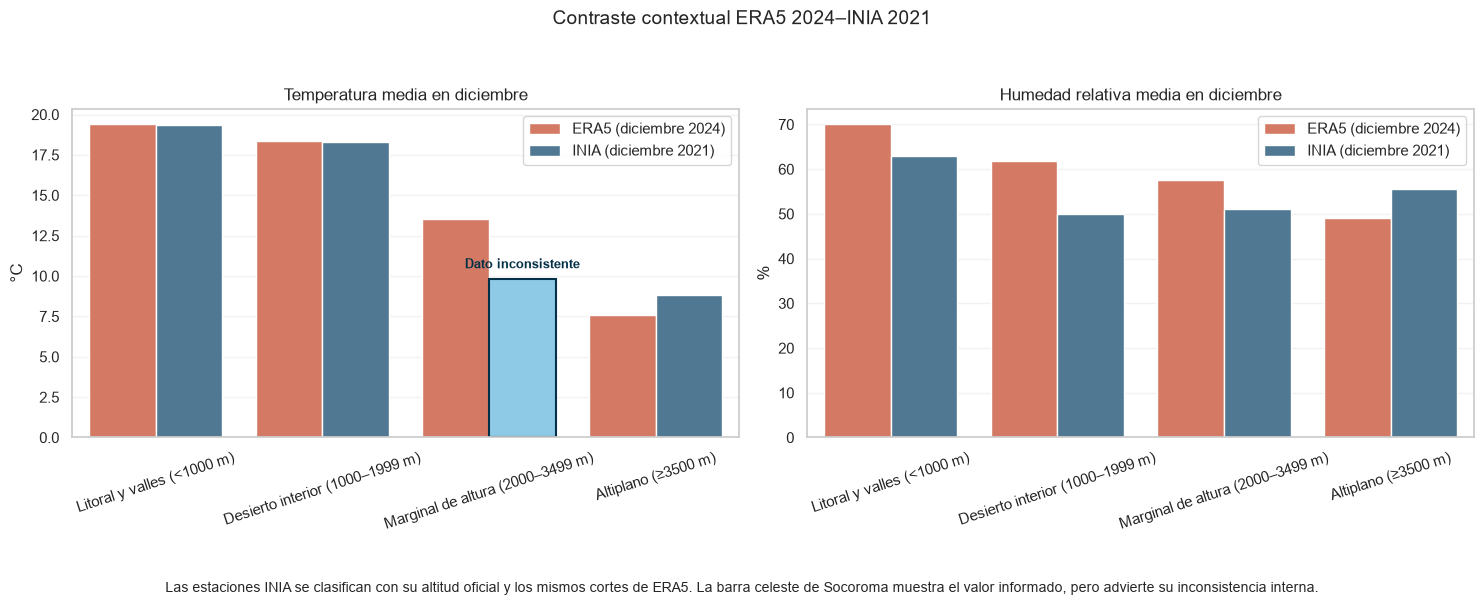

In [6]:
# Pisos altitudinales operativos del análisis, aplicados de forma común a ERA5, CIREN e INIA.
ZONE_ORDER = [
    "Litoral y valles (<1000 m)",
    "Desierto interior (1000–1999 m)",
    "Marginal de altura (2000–3499 m)",
    "Altiplano (≥3500 m)",
]
ZONE_BINS = [-np.inf, 1000, 2000, 3500, np.inf]

# Clasifica los valores de altitud con los intervalos operativos definidos arriba.
def altitude_zone(values):
    return pd.cut(
        values,
        bins=ZONE_BINS,
        labels=ZONE_ORDER,
        right=False,
        ordered=True,
    )

climate = keyed.copy() #Crea una copia del DataFrame 'keyed' (grid_id, year, epiweek) para trabajar con los datos climáticos.
climate["zona_altitud"] = altitude_zone(climate["alt_mean"])  # Clasifica la altitud media de cada celda.

# Se agrupa el DataFrame 'climate' por zona de altitud, calculando estadísticas agregadas para cada zona, incluyendo número de grid_id únicos, media y percentiles de temperatura media y humedad relativa, y media de altitud.
climate_by_zone = (
    climate.groupby("zona_altitud", observed=True)
    .agg(
        grid_id=("grid_id", "nunique"),
        tmean_c_media=("tmean_c", "mean"),
        tmean_c_p05=("tmean_c", lambda values: values.quantile(0.05)),
        tmean_c_p95=("tmean_c", lambda values: values.quantile(0.95)),
        rh_mean_media=("rh_mean", "mean"),
        rh_mean_p05=("rh_mean", lambda values: values.quantile(0.05)),
        rh_mean_p95=("rh_mean", lambda values: values.quantile(0.95)),
        alt_mean=("alt_mean", "mean"),
    )
    .reindex(ZONE_ORDER)
    .reset_index()
)

# Se construye un DataFrame 'calendar_for_join' que contiene las columnas 'epiweek', 'start_date' y 'end_date' del calendario epidemiológico, y se calcula el punto medio de la semana epidemiológica sumando 3 días a la fecha de inicio.
calendar_for_join = epi_calendar[["epiweek", "start_date", "end_date"]].copy()
calendar_for_join["week_midpoint"] = (
    pd.to_datetime(calendar_for_join["start_date"]) + pd.Timedelta(days=3)
)
# Selecciona las filas correspondientes a diciembre de 2024
december_2024 = climate.merge(
    calendar_for_join[["epiweek", "week_midpoint"]],
    on="epiweek",
    how="left",
    validate="many_to_one",
)
# Filtra las filas de 'december_2024' para conservar solo aquellas cuyo punto medio de la semana cae en diciembre (mes 12).
december_2024 = december_2024.loc[
    december_2024["week_midpoint"].dt.month.eq(12)
]
# Se agrupa el DataFrame 'december_2024' por zona de altitud, calculando estadísticas agregadas para cada zona, incluyendo número de semanas únicas, media de temperatura mínima, media y máxima, y media de humedad relativa.
december_by_zone = (
    december_2024.groupby("zona_altitud", observed=True)
    .agg(
        semanas=("epiweek", "nunique"),
        tmin_c=("tmin_c", "mean"),
        tmean_c=("tmean_c", "mean"),
        tmax_c=("tmax_c", "mean"),
        rh_mean=("rh_mean", "mean"),
    )
    .reindex(ZONE_ORDER)
    .reset_index()
)

# Verificar que la zona estandarizada del CSV coincide con la derivada de la altitud oficial.
inia = inia.copy()
inia["zona_altitud_calculada"] = altitude_zone(inia["altitud_m"]).astype("string")
inia_zone_mismatch = inia["zona_altitud_calculada"].ne(inia["zona_altitud"])
if inia_zone_mismatch.any():
    raise ValueError(
        "Hay estaciones INIA cuya zona_altitud no coincide con su altitud_m: "
        f"{inia.loc[inia_zone_mismatch, 'estacion'].tolist()}"
    )
inia["zona_altitud"] = pd.Categorical(
    inia["zona_altitud"], categories=ZONE_ORDER, ordered=True
)

# Socoroma conserva su temperatura informada, pero queda marcada como inconsistente.
inia_for_comparison = inia.copy()
invalid_temperature = (
    inia_for_comparison["inconsistencia_interna_fuente"]
    .astype("boolean")
    .fillna(False)
)
# Se crean columnas adicionales en el DataFrame 'inia_for_comparison' para facilitar la comparación con los datos de ERA5. Se renombran las columnas de temperatura media y humedad relativa, y se crean columnas booleanas que indican si la temperatura es válida o inconsistente según la información de INIA.
inia_for_comparison["tmean_c"] = inia_for_comparison["temperatura_media_c"]
inia_for_comparison["rh_mean"] = inia_for_comparison["humedad_relativa_pct"]
inia_for_comparison["temperatura_valida"] = (
    inia_for_comparison["tmean_c"].notna() & ~invalid_temperature
)
inia_for_comparison["temperatura_inconsistente"] = (
    inia_for_comparison["tmean_c"].notna() & invalid_temperature
)
# Se agrupa el DataFrame 'inia_for_comparison' por zona de altitud, calculando estadísticas agregadas para cada zona, incluyendo número de estaciones únicas, número de estaciones con temperatura informada, 
# número de estaciones con temperatura válida, número de estaciones con temperatura inconsistente, número de estaciones con humedad relativa válida, media de temperatura y media de humedad relativa.
inia_by_zone = (
    inia_for_comparison.groupby("zona_altitud", observed=True)
    .agg(
        estaciones_inia=("estacion", "nunique"),
        estaciones_temperatura_informadas=("tmean_c", "count"),
        estaciones_temperatura_validas=("temperatura_valida", "sum"),
        estaciones_temperatura_inconsistentes=("temperatura_inconsistente", "sum"),
        estaciones_humedad_validas=("rh_mean", "count"),
        tmean_c=("tmean_c", "mean"),
        rh_mean=("rh_mean", "mean"),
    )
    .reindex(ZONE_ORDER)
    .reset_index()
)
inia_by_zone["temperatura_inconsistente"] = (
    inia_by_zone["estaciones_temperatura_inconsistentes"].gt(0)
)

# Comparación de las fuentes para diciembre
era5_december_comparison = december_by_zone[
    ["zona_altitud", "tmean_c", "rh_mean"]
].copy()
era5_december_comparison["fuente_periodo"] = "ERA5 (diciembre 2024)"
era5_december_comparison["temperatura_inconsistente"] = False # Ya se había verificado la integridad de Era 5
inia_december_comparison = inia_by_zone[
    ["zona_altitud", "tmean_c", "rh_mean", "temperatura_inconsistente"]
].copy()

inia_december_comparison["fuente_periodo"] = "INIA (diciembre 2021)"
# Se combinan los DataFrames de comparación de ERA5 y INIA para diciembre en un solo DataFrame 'december_source_comparison', ignorando los índices originales. Luego, se asegura que la columna 'zona_altitud' sea categórica con un orden específico definido por 'ZONE_ORDER'.
december_source_comparison = pd.concat(
    [era5_december_comparison, inia_december_comparison],
    ignore_index=True,
)
december_source_comparison["zona_altitud"] = pd.Categorical(
    december_source_comparison["zona_altitud"],
    categories=ZONE_ORDER,
    ordered=True,
)

# Guardar los resultados de los análisis en archivos CSV para su posterior revisión o uso.
climate_by_zone.to_csv(DIAG_DIR / "era5_climate_by_altitude_zone.csv", index=False)
december_by_zone.to_csv(DIAG_DIR / "era5_december_2024_by_altitude_zone.csv", index=False)
december_source_comparison.to_csv(
    DIAG_DIR / "era5_inia_december_altitude_comparison.csv",
    index=False,
)

# Mostrar tablas resumidas de los análisis realizados
show_table(
    "Clima ERA5 2024 por piso altitudinal operativo",
    "Resume todas las observaciones grilla–semana clasificables mediante alt_mean. Los pisos son categorías analíticas del estudio; las medias y percentiles no están ponderados por población.",
    climate_by_zone,
)
show_table(
    "ERA5 en semanas con punto medio en diciembre de 2024",
    "Resumen construido exclusivamente para un contraste estacional aproximado con INIA. Incluye semanas epidemiológicas cuyo miércoles cae en diciembre; tmin_c y tmax_c son medias de los valores semanales, no extremos absolutos del mes.",
    december_by_zone,
)
show_table(
    "Referencia INIA para diciembre de 2021",
    "Cada estación conserva la zona territorial del informe y muestra, por separado, la zona altitudinal derivada de su altitud oficial DMC-SACLIM. Socoroma está marcado por una inconsistencia mínima–media en la fuente transcrita.",
    inia[[
        "estacion", "zona_inia", "codigo_dmc_saclim", "altitud_m",
        "zona_altitud", "temperatura_media_c", "humedad_relativa_pct",
        "inconsistencia_interna_fuente",
    ]],
    max_rows=20,
)
show_table(
    "Referencia INIA resumida por piso altitudinal",
    "Promedios usados en los gráficos comparativos. Se distinguen las temperaturas informadas, las válidas y las inconsistentes. La media de Socoroma se conserva en el gráfico, pero se identifica visualmente como inconsistente.",
    inia_by_zone,
)

source_order = ["ERA5 (diciembre 2024)", "INIA (diciembre 2021)"]
source_colors = {
    "ERA5 (diciembre 2024)": "#e76f51",
    "INIA (diciembre 2021)": "#457b9d",
}
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, variable, title, ylabel in [
    (axes[0], "tmean_c", "Temperatura media en diciembre", "°C"),
    (axes[1], "rh_mean", "Humedad relativa media en diciembre", "%"),
]:
    sns.barplot(
        data=december_source_comparison,
        x="zona_altitud",
        y=variable,
        hue="fuente_periodo",
        order=ZONE_ORDER,
        hue_order=source_order,
        palette=source_colors,
        errorbar=None,
        ax=ax,
    )
    ax.set(title=title, xlabel="", ylabel=ylabel)
    ax.tick_params(axis="x", rotation=18)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(title="")

# Destacar las barras INIA que incorporan una temperatura marcada como inconsistente.
inconsistent_blue = "#8ecae6"
inia_temperature_container = axes[0].containers[source_order.index("INIA (diciembre 2021)")]
inconsistent_zones = inia_by_zone.loc[
    inia_by_zone["temperatura_inconsistente"], "zona_altitud"
]
for zone in inconsistent_zones:
    zone_position = ZONE_ORDER.index(str(zone))
    bar = inia_temperature_container.patches[zone_position]
    bar.set_facecolor(inconsistent_blue)
    bar.set_edgecolor("#023047")
    bar.set_linewidth(1.5)
    if np.isfinite(bar.get_height()):
        axes[0].annotate(
            "Dato inconsistente",
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 6),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            color="#023047",
        )
fig.suptitle("Contraste contextual ERA5 2024–INIA 2021", fontsize=14)
fig.text(
    0.5,
    0.01,
    "Las estaciones INIA se clasifican con su altitud oficial y los mismos cortes de ERA5. "
    "La barra celeste de Socoroma muestra el valor informado, pero advierte su inconsistencia interna.",
    ha="center",
    fontsize=10,
)
fig.tight_layout(rect=(0, 0.08, 1, 0.94))
fig.savefig(
    FIG_DIR / "era5_inia_december_temperature_humidity.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()


## Precipitación: unidad y comparación contextual con CIREN

Como `tp_sum` no documenta su unidad, se comparan dos escenarios: valor almacenado en milímetros o conversión de metros a milímetros. Las acumulaciones anuales por piso altitudinal se contrastan con CIREN sólo para detectar diferencias de escala; no se adopta una unidad automáticamente.


### Precipitación anual ERA5 frente a la referencia climatológica CIREN

Compara promedios por piso altitudinal con dos escenarios de unidad para tp_sum. CIREN resume periodos históricos; la tabla busca detectar órdenes de magnitud incompatibles, no validar igualdad con 2024.

**Dimensiones:** 4 filas × 16 columnas.

,zona_altitud,grillas,tp_media_unidad_almacenada,tp_mediana_unidad_almacenada,tp_min_unidad_almacenada,tp_max_unidad_almacenada,estaciones_referencia,precipitacion_media_ciren_mm,precipitacion_mediana_ciren_mm,precipitacion_min_ciren_mm,precipitacion_max_ciren_mm,escenario_si_metros_mm,escenario_si_milimetros_mm,factor_hasta_media_ciren,compatible_si_metros,unidad_documentada_en_parquet
0,Litoral y valles (<1000 m),475,1.566777,0.879742,0.162719,4.658348,3,0.900000,0.8,0.8,1.1,1566.776632,1.566777,0.574428,False,False
1,Desierto interior (1000–1999 m),547,1.611786,1.331957,0.295798,5.171747,1,13.500000,13.5,13.5,13.5,1611.785806,1.611786,8.375803,False,False
2,Marginal de altura (2000–3499 m),554,4.524092,4.452878,1.051560,7.474928,3,111.033333,123.5,41.7,167.9,4524.091517,4.524092,24.542681,False,False
3,Altiplano (≥3500 m),1828,6.764843,6.821904,3.288170,10.131788,13,316.807692,308.2,202.1,419.4,6764.842575,6.764843,46.831495,False,False


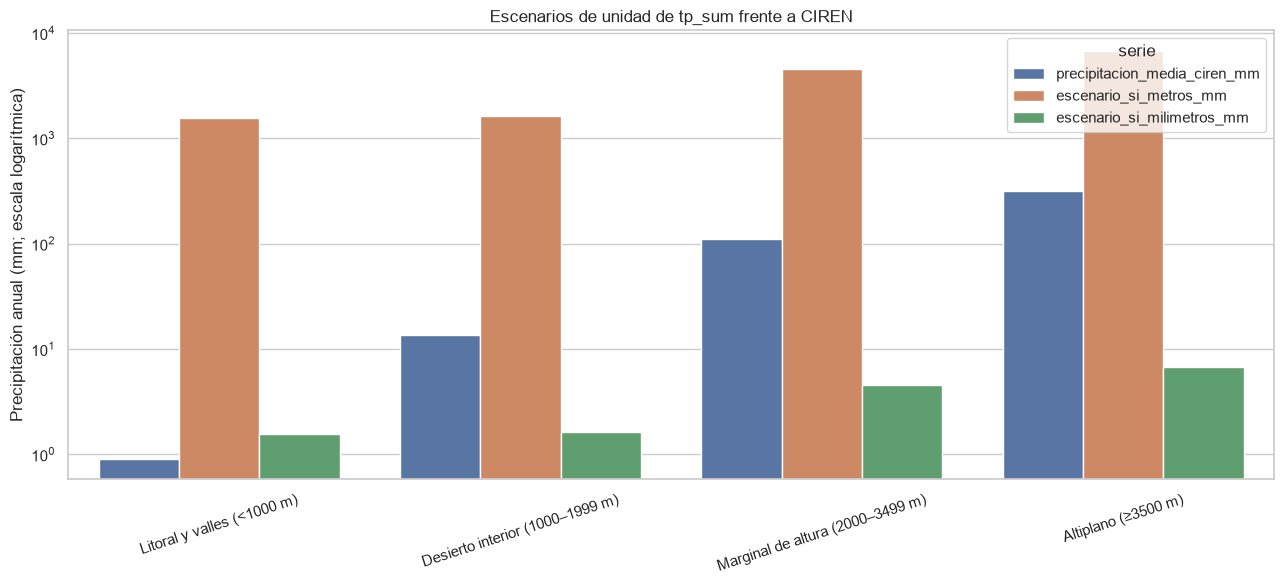

In [7]:
# Comparación de la precipitación anual ERA5 frente a la referencia climatológica CIREN
annual_tp_grid = (
    climate.groupby(["grid_id", "zona_altitud"], observed=True)["tp_sum"]
    .sum(min_count=1)
    .rename("tp_sum_anual_unidad_almacenada")
    .reset_index()
)
# Se agrupa el DataFrame 'annual_tp_grid' por zona de altitud, calculando estadísticas agregadas para cada zona, incluyendo número de grillas, media, mediana, mínimo y máximo de la precipitación anual por unidad almacenada.
annual_tp_zone = (
    annual_tp_grid.groupby("zona_altitud", observed=True)
    .agg(
        grillas=("grid_id", "size"),
        tp_media_unidad_almacenada=("tp_sum_anual_unidad_almacenada", "mean"),
        tp_mediana_unidad_almacenada=("tp_sum_anual_unidad_almacenada", "median"),
        tp_min_unidad_almacenada=("tp_sum_anual_unidad_almacenada", "min"),
        tp_max_unidad_almacenada=("tp_sum_anual_unidad_almacenada", "max"),
    )
    .reindex(ZONE_ORDER)
    .reset_index()
)
# Se agrupa el DataFrame 'ciren' por zona de altitud, calculando estadísticas agregadas para cada zona, incluyendo número de estaciones de referencia, media, mediana, mínimo y máximo de la precipitación anual media en milímetros.
ciren_zone_reference = (
    ciren.groupby("zona_altitud", observed=True)
    .agg(
        estaciones_referencia=("estacion", "size"),
        precipitacion_media_ciren_mm=("precipitacion_anual_media_mm", "mean"),
        precipitacion_mediana_ciren_mm=("precipitacion_anual_media_mm", "median"),
        precipitacion_min_ciren_mm=("precipitacion_anual_media_mm", "min"),
        precipitacion_max_ciren_mm=("precipitacion_anual_media_mm", "max"),
    )
    .reindex(ZONE_ORDER)
    .reset_index()
)
#   Se realiza un merge entre los DataFrames 'annual_tp_zone' y 'ciren_zone_reference' utilizando la columna 'zona_altitud' como clave, y se calculan nuevas columnas para comparar la precipitación anual de ERA5 con la referencia climatológica de CIREN. Se crean columnas que representan la precipitación anual en metros y milímetros, así como un factor de compatibilidad y una columna booleana que indica si los valores son compatibles según ciertos criterios.
precipitation_comparison = annual_tp_zone.merge(
    ciren_zone_reference,
    on="zona_altitud",
    how="left",
)
precipitation_comparison["escenario_si_metros_mm"] = (
    precipitation_comparison["tp_media_unidad_almacenada"] * 1000
)
precipitation_comparison["escenario_si_milimetros_mm"] = (
    precipitation_comparison["tp_media_unidad_almacenada"]
)
precipitation_comparison["factor_hasta_media_ciren"] = (
    precipitation_comparison["precipitacion_media_ciren_mm"]
    / precipitation_comparison["tp_media_unidad_almacenada"]
)
precipitation_comparison["compatible_si_metros"] = (
    precipitation_comparison["escenario_si_metros_mm"]
    .between(
        precipitation_comparison["precipitacion_min_ciren_mm"] / 2,
        precipitation_comparison["precipitacion_max_ciren_mm"] * 2,
    )
    .fillna(False)
)
precipitation_comparison["unidad_documentada_en_parquet"] = tp_unit_documented

precipitation_comparison.to_csv(
    DIAG_DIR / "era5_precipitation_vs_ciren.csv",
    index=False,
)
# Mostrar la tabla de comparación de precipitación anual entre ERA5 y CIREN
show_table(
    "Precipitación anual ERA5 frente a la referencia climatológica CIREN",
    "Compara promedios por piso altitudinal con dos escenarios de unidad para tp_sum. CIREN resume periodos históricos; la tabla busca detectar órdenes de magnitud incompatibles, no validar igualdad con 2024.",
    precipitation_comparison,
)

plot_precipitation = precipitation_comparison.melt(
    id_vars="zona_altitud",
    value_vars=[
        "precipitacion_media_ciren_mm",
        "escenario_si_metros_mm",
        "escenario_si_milimetros_mm",
    ],
    var_name="serie",
    value_name="precipitacion_anual_mm",
)
fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(
    data=plot_precipitation,
    x="zona_altitud",
    y="precipitacion_anual_mm",
    hue="serie",
    ax=ax,
)
ax.set_yscale("log")
ax.set(
    title="Escenarios de unidad de tp_sum frente a CIREN",
    xlabel="",
    ylabel="Precipitación anual (mm; escala logarítmica)",
)
ax.tick_params(axis="x", rotation=18)
fig.tight_layout()
fig.savefig(FIG_DIR / "era5_precipitation_vs_ciren.png", dpi=180, bbox_inches="tight")
plt.show()


## Inventario de GeoTIFF NDVI

Se inventarían cuatro métricas y 26 bisemanas por métrica. `damaged_backup` queda fuera del análisis.


In [8]:
# Inventario de archivos GeoTIFF NDVI
N_BIWEEKS = N_EPIWEEKS // 2 # deben haber 26 archivos por métrica, uno por bisemana
# Se define un diccionario `STAT_CONFIG` que contiene la configuración para diferentes métricas de NDVI, incluyendo la carpeta donde se encuentran los archivos, el sufijo del nombre del archivo y los valores esperados mínimo y máximo para cada métrica.
STAT_CONFIG = {
    "ndvi_media_bisemanal": {"folder": "media_bisemanal", "suffix": "mean", "expected_min": -1.0, "expected_max": 1.0},
    "ndvi_maximo_bisemanal": {"folder": "maximo_bisemanal", "suffix": "max", "expected_min": -1.0, "expected_max": 1.0},
    "ndvi_minimo_bisemanal": {"folder": "minimo_bisemanal", "suffix": "min", "expected_min": -1.0, "expected_max": 1.0},
    "ndvi_desvest_bisemanal": {"folder": "desvest_bisemanal", "suffix": "std", "expected_min": 0.0, "expected_max": np.inf},
}

# Se define una función `biweek_from_filename` que extrae el número de bisemana de un nombre de archivo utilizando una expresión regular. 
# La función busca un patrón que coincida con "_BI" seguido de dos dígitos y devuelve el número de bisemana como un entero. 
# Si no se encuentra el patrón, devuelve `None`.
def biweek_from_filename(path):
    match = re.search(r"_BI(\d{2})_", path.name, flags=re.IGNORECASE)
    return int(match.group(1)) if match else None

# Se construye un inventario de archivos GeoTIFF NDVI recorriendo cada métrica definida en `STAT_CONFIG`. 
# Para cada métrica, se busca en la carpeta correspondiente los archivos que coincidan con el sufijo especificado. 
inventory_rows = []
for metric, config in STAT_CONFIG.items():
    folder = NDVI_EXTERNAL_DIR / config["folder"]
    candidates = (
        sorted(folder.glob(f"*_{config['suffix']}.tif"))
        + sorted(folder.glob(f"*_{config['suffix']}.tiff"))
        if folder.is_dir() else []
    )
    for path in candidates:
        inventory_rows.append(
            {
                "metric": metric,
                "folder": str(folder),
                "biweek": biweek_from_filename(path),
                "path": str(path),
                "filename": path.name,
                "bytes": path.stat().st_size,
                "mtime_ns": path.stat().st_mtime_ns,
            }
        )

# Se crea un DataFrame `ndvi_inventory` a partir de la lista `inventory_rows`. 
# Si el DataFrame está vacío, se lanza un error indicando que no se encontraron archivos GeoTIFF NDVI en el directorio especificado.
ndvi_inventory = pd.DataFrame(inventory_rows)
if ndvi_inventory.empty:
    raise FileNotFoundError(f"No se encontraron GeoTIFF NDVI en {NDVI_EXTERNAL_DIR}")

# Se filtran las filas del inventario para conservar solo aquellas con bisemanas válidas (entre 1 y N_BIWEEKS).
valid_biweek = ndvi_inventory["biweek"].between(1, N_BIWEEKS)
duplicates = (
    ndvi_inventory.loc[valid_biweek]
    .groupby(["metric", "biweek"])
    .size()
    .rename("archivos")
    .reset_index()
)
duplicate_raster_keys = duplicates.loc[duplicates["archivos"].gt(1)]

# Se construye un resumen del inventario de archivos GeoTIFF NDVI, verificando que cada métrica tenga las 26 bisemanas esperadas y señalando periodos faltantes, adicionales o duplicados antes de leer los píxeles.
inventory_summary_rows = []
expected_biweeks = set(range(1, N_BIWEEKS + 1))
for metric in STAT_CONFIG:
    metric_inventory_all = ndvi_inventory.loc[ndvi_inventory["metric"].eq(metric)]
    metric_inventory = metric_inventory_all.loc[
        metric_inventory_all["biweek"].between(1, N_BIWEEKS)
    ]
    found_all = set(metric_inventory_all["biweek"].dropna().astype(int))
    found = found_all & expected_biweeks
    inventory_summary_rows.append(
        {
            "metric": metric,
            "archivos_validos": len(metric_inventory),
            "bisemanas_unicas": len(found),
            "bisemanas_faltantes": sorted(expected_biweeks - found),
            "bisemanas_adicionales": sorted(found_all - expected_biweeks),
            "duplicados": int(
                duplicate_raster_keys["metric"].eq(metric).sum()
            ),
        }
    )
ndvi_inventory_summary = pd.DataFrame(inventory_summary_rows)

# Guardar los resultados del inventario de archivos GeoTIFF NDVI y su resumen en archivos CSV para su posterior revisión o uso.
ndvi_inventory.to_csv(DIAG_DIR / "ndvi_file_inventory.csv", index=False)
ndvi_inventory_summary.to_csv(DIAG_DIR / "ndvi_file_inventory_summary.csv", index=False)

show_table(
    "Inventario de GeoTIFF NDVI por métrica",
    "Comprueba si cada producto contiene las 26 bisemanas esperadas y señala periodos faltantes, adicionales o duplicados antes de leer los píxeles.",
    ndvi_inventory_summary,
)
if not duplicate_raster_keys.empty:
    show_table(
        "Bisemanas NDVI con archivos duplicados",
        "Cada fila identifica una combinación métrica–bisemana con más de un GeoTIFF candidato; estos casos deben resolverse antes de agregar.",
        duplicate_raster_keys,
    )


### Inventario de GeoTIFF NDVI por métrica

Comprueba si cada producto contiene las 26 bisemanas esperadas y señala periodos faltantes, adicionales o duplicados antes de leer los píxeles.

**Dimensiones:** 4 filas × 6 columnas.

,metric,archivos_validos,bisemanas_unicas,bisemanas_faltantes,bisemanas_adicionales,duplicados
0,ndvi_media_bisemanal,26,26,[],[],0
1,ndvi_maximo_bisemanal,26,26,[],[],0
2,ndvi_minimo_bisemanal,26,26,[],[],0
3,ndvi_desvest_bisemanal,26,26,[],[],0


## Metadatos y alineación de los GeoTIFF

Se revisan CRS, resolución, dimensiones, transformación, bandas, tipo y `nodata`. La comparación píxel a píxel exige alineación espacial.


In [9]:
# Evaluación de la consistencia espacial de los archivos GeoTIFF NDVI
raster_metadata_rows = []
for row in ndvi_inventory.itertuples(index=False):
    try:
        with rasterio.open(row.path) as src:
            signature = ( # Se construye una firma de alineación para cada archivo GeoTIFF NDVI, que incluye el CRS (sistema de referencia de coordenadas), el ancho y alto de la imagen, y la transformación espacial. Esta firma se utiliza para verificar la consistencia espacial entre los archivos.
                src.crs.to_string() if src.crs else None,
                src.width,
                src.height,
                tuple(src.transform),
            )
            raster_metadata_rows.append(
                # Se agregan los metadatos del archivo GeoTIFF NDVI al inventario de metadatos, incluyendo la métrica, bisemana, ruta del archivo, estado (OK o DAMAGED), driver, CRS, dimensiones, resolución, 
                # número de bandas, tipo de datos, valor de nodata, límites espaciales y firma de alineación.
                {
                    "metric": row.metric,
                    "biweek": row.biweek,
                    "path": row.path,
                    "bytes": row.bytes,
                    "mtime_ns": row.mtime_ns,
                    "status": "OK",
                    "driver": src.driver,
                    "crs": src.crs.to_string() if src.crs else None,
                    "width": src.width,
                    "height": src.height,
                    "resolution_x": src.res[0],
                    "resolution_y": src.res[1],
                    "bands": src.count,
                    "dtype": src.dtypes[0] if src.dtypes else None,
                    "nodata": src.nodata,
                    "bounds": tuple(src.bounds),
                    "alignment_signature": repr(signature),
                    "error": "",
                }
            )
# Si ocurre algún error al abrir o leer el archivo GeoTIFF NDVI, se captura la excepción y se registra en el inventario de metadatos con el estado "DAMAGED" y el mensaje de error correspondiente.
    except Exception as exc:
        raster_metadata_rows.append(
            {
                "metric": row.metric,
                "biweek": row.biweek,
                "path": row.path,
                "bytes": row.bytes,
                "mtime_ns": row.mtime_ns,
                "status": "DAMAGED",
                "error": f"{type(exc).__name__}: {exc}",
            }
        )

# Se crea un DataFrame `raster_metadata` a partir de la lista `raster_metadata_rows`, que contiene los metadatos de los archivos GeoTIFF NDVI
# y su estado de consistencia espacial. Luego, se agrupa por bisemana para evaluar la alineación espacial de las cuatro métricas, 
# verificando si todas comparten el mismo CRS, dimensiones y transformación espacial.
raster_metadata = pd.DataFrame(raster_metadata_rows)
alignment_by_biweek = (
    raster_metadata.loc[raster_metadata["status"].eq("OK")]
    .groupby("biweek")
    .agg(
        metrics=("metric", "nunique"),
        signatures=("alignment_signature", "nunique"),
        crs=("crs", "nunique"),
    )
    .reset_index()
)
alignment_by_biweek["aligned"] = (
    alignment_by_biweek["metrics"].eq(len(STAT_CONFIG))
    & alignment_by_biweek["signatures"].eq(1)
    & alignment_by_biweek["crs"].eq(1)
)

raster_metadata.to_csv(DIAG_DIR / "ndvi_raster_metadata.csv", index=False)
alignment_by_biweek.to_csv(DIAG_DIR / "ndvi_alignment_by_biweek.csv", index=False)

show_table(
    "Metadatos técnicos de los GeoTIFF NDVI",
    "Inventario técnico de CRS, dimensiones, resolución, bandas, tipo, nodata, extensión y firma de alineación. La vista es una muestra; el CSV diagnóstico conserva todos los archivos.",
    raster_metadata,
    max_rows=5,
)
show_table(
    "Alineación espacial de las cuatro métricas por bisemana",
    "Una bisemana se considera alineada cuando están presentes las cuatro métricas y comparten CRS, dimensiones y transformación espacial, condición necesaria para compararlas píxel a píxel.",
    alignment_by_biweek,
)


### Metadatos técnicos de los GeoTIFF NDVI

Inventario técnico de CRS, dimensiones, resolución, bandas, tipo, nodata, extensión y firma de alineación. La vista es una muestra; el CSV diagnóstico conserva todos los archivos.

**Dimensiones:** 104 filas × 18 columnas. Se muestran las primeras 5 filas.

,metric,biweek,path,bytes,mtime_ns,status,driver,crs,width,height,resolution_x,resolution_y,bands,dtype,nodata,bounds,alignment_signature,error
0,ndvi_media_bisemanal,1,D:\GeoTIFF NDVI\media_bisemanal\ndvi_arica_y_p...,1375247346,1779116740000000000,OK,GTiff,EPSG:32719,15714,19310,10.0,10.0,1,float32,-inf,"(353480.0, 7873140.0, 510620.0, 8066240.0)","('EPSG:32719', 15714, 19310, (10.0, 0.0, 35348...",
1,ndvi_media_bisemanal,2,D:\GeoTIFF NDVI\media_bisemanal\ndvi_arica_y_p...,1364485678,1779121068000000000,OK,GTiff,EPSG:32719,15714,19310,10.0,10.0,1,float32,-inf,"(353480.0, 7873140.0, 510620.0, 8066240.0)","('EPSG:32719', 15714, 19310, (10.0, 0.0, 35348...",
2,ndvi_media_bisemanal,3,D:\GeoTIFF NDVI\media_bisemanal\ndvi_arica_y_p...,1321854681,1779121242000000000,OK,GTiff,EPSG:32719,15714,19310,10.0,10.0,1,float32,-inf,"(353480.0, 7873140.0, 510620.0, 8066240.0)","('EPSG:32719', 15714, 19310, (10.0, 0.0, 35348...",
3,ndvi_media_bisemanal,4,D:\GeoTIFF NDVI\media_bisemanal\ndvi_arica_y_p...,777263574,1779121388000000000,OK,GTiff,EPSG:32719,15714,19310,10.0,10.0,1,float32,-inf,"(353480.0, 7873140.0, 510620.0, 8066240.0)","('EPSG:32719', 15714, 19310, (10.0, 0.0, 35348...",
4,ndvi_media_bisemanal,5,D:\GeoTIFF NDVI\media_bisemanal\ndvi_arica_y_p...,372065467,1779121488000000000,OK,GTiff,EPSG:32719,15714,19310,10.0,10.0,1,float32,-inf,"(353480.0, 7873140.0, 510620.0, 8066240.0)","('EPSG:32719', 15714, 19310, (10.0, 0.0, 35348...",


### Alineación espacial de las cuatro métricas por bisemana

Una bisemana se considera alineada cuando están presentes las cuatro métricas y comparten CRS, dimensiones y transformación espacial, condición necesaria para compararlas píxel a píxel.

**Dimensiones:** 26 filas × 5 columnas.

,biweek,metrics,signatures,crs,aligned
0,1,4,1,1,True
1,2,4,1,1,True
2,3,4,1,1,True
3,4,4,1,1,True
4,5,4,1,1,True
5,6,4,1,1,True
6,7,4,1,1,True
7,8,4,1,1,True
8,9,4,1,1,True
9,10,4,1,1,True


## Lectura completa de píxeles dentro del área de estudio

Se calculan por GeoTIFF conteos, media, desviación, extremos y valores fuera de rango. Los percentiles usan una muestra reproducible por bloque; la lectura abarca 104 archivos.


Escaneando BI01...
Escaneando BI02...
Escaneando BI03...
Escaneando BI04...
Escaneando BI05...
Escaneando BI06...
Escaneando BI07...
Escaneando BI08...
Escaneando BI09...
Escaneando BI10...
Escaneando BI11...
Escaneando BI12...
Escaneando BI13...
Escaneando BI14...
Escaneando BI15...
Escaneando BI16...
Escaneando BI17...
Escaneando BI18...
Escaneando BI19...
Escaneando BI20...
Escaneando BI21...
Escaneando BI22...
Escaneando BI23...
Escaneando BI24...
Escaneando BI25...
Escaneando BI26...


### Calidad de píxeles NDVI dentro del área de estudio

Resume cobertura válida y distribución por métrica y bisemana. Media, desviación, mínimo y máximo son exactos; p01, mediana y p99 provienen de una muestra reproducible por bloques.

**Dimensiones:** 104 filas × 16 columnas.

,metric,biweek,path,study_pixel_count,valid_pixel_count,nodata_pixel_count,coverage_pct,mean,std,min,p01_approx,median_approx,p99_approx,max,outside_expected_range_pixels,quantiles_are_approximate
0,ndvi_media_bisemanal,1,D:\GeoTIFF NDVI\media_bisemanal\ndvi_arica_y_p...,168737096,166284091,2453005,98.546256,0.072927,0.067884,-1.000000,-0.011729,0.062601,0.401843,1.000000,0,True
1,ndvi_maximo_bisemanal,1,D:\GeoTIFF NDVI\maximo_bisemanal\ndvi_arica_y_...,168737096,166284091,2453005,98.546256,0.080235,0.072132,-1.000000,-0.006390,0.068558,0.443107,1.000000,0,True
2,ndvi_minimo_bisemanal,1,D:\GeoTIFF NDVI\minimo_bisemanal\ndvi_arica_y_...,168737096,166284091,2453005,98.546256,0.065509,0.065436,-1.000000,-0.025243,0.056311,0.360420,1.000000,0,True
3,ndvi_desvest_bisemanal,1,D:\GeoTIFF NDVI\desvest_bisemanal\ndvi_arica_y...,168737096,166284091,2453005,98.546256,0.006578,0.010758,0.000000,0.000000,0.004332,0.049926,0.697997,0,True
4,ndvi_media_bisemanal,2,D:\GeoTIFF NDVI\media_bisemanal\ndvi_arica_y_p...,168737096,164500904,4236192,97.489472,0.072987,0.069031,-1.000000,-0.013901,0.062295,0.408769,1.000000,0,True
5,ndvi_maximo_bisemanal,2,D:\GeoTIFF NDVI\maximo_bisemanal\ndvi_arica_y_...,168737096,164500904,4236192,97.489472,0.079562,0.073086,-1.000000,-0.007434,0.067399,0.432740,1.000000,0,True
6,ndvi_minimo_bisemanal,2,D:\GeoTIFF NDVI\minimo_bisemanal\ndvi_arica_y_...,168737096,164500904,4236192,97.489472,0.066330,0.066809,-1.000000,-0.025165,0.056397,0.368656,1.000000,0,True
7,ndvi_desvest_bisemanal,2,D:\GeoTIFF NDVI\desvest_bisemanal\ndvi_arica_y...,168737096,164500904,4236192,97.489472,0.005964,0.010472,0.000000,0.000000,0.003581,0.047300,0.794691,0,True
8,ndvi_media_bisemanal,3,D:\GeoTIFF NDVI\media_bisemanal\ndvi_arica_y_p...,168737096,164140105,4596991,97.275649,0.065506,0.064312,-1.000000,-0.016197,0.057398,0.378585,1.000000,0,True
9,ndvi_maximo_bisemanal,3,D:\GeoTIFF NDVI\maximo_bisemanal\ndvi_arica_y_...,168737096,164140105,4596991,97.275649,0.071628,0.069485,-1.000000,-0.015024,0.062219,0.403026,1.000000,0,True


### Consistencia píxel a píxel entre NDVI mínimo, medio y máximo

Para píxeles válidos en las tres métricas se comprueba mínimo ≤ media ≤ máximo. Solo se evalúan bisemanas espacialmente alineadas.

**Dimensiones:** 26 filas × 4 columnas.

,biweek,comparable_pixels,failed_min_mean_max,failed_pct
0,1,166284091,0,0.0
1,2,164500904,0,0.0
2,3,164140105,0,0.0
3,4,104463369,0,0.0
4,5,34923466,0,0.0
5,6,167718524,0,0.0
6,7,166952676,0,0.0
7,8,168132050,0,0.0
8,9,168185360,0,0.0
9,10,165449793,0,0.0


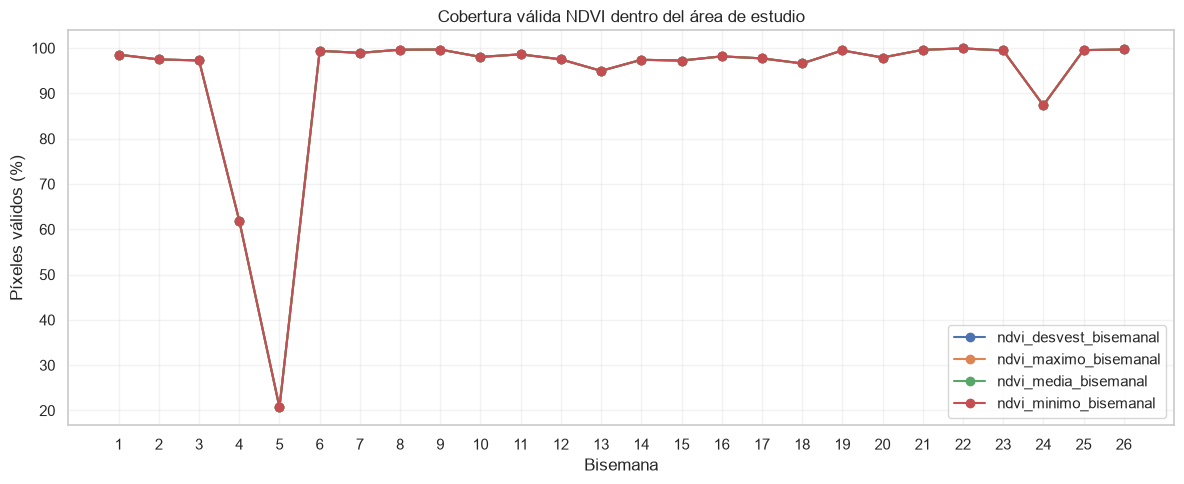

In [10]:
# Diccionario para guardar la geometría reproyectada del área de estudio en diferentes sistemas de referencia de coordenadas (CRS). Esto evita recalcular la geometría para el mismo CRS varias veces, mejorando la eficiencia.
_study_geometry_cache = {} 
# Se define una función `study_geometry_for_crs` que toma un sistema de referencia de coordenadas (CRS) como entrada y devuelve la geometría de estudio proyectada en ese CRS.
def study_geometry_for_crs(crs): # Analiza la geometría del área de estudio completa. 
    key = CRS.from_user_input(crs).to_string() # Recibe el CRS y lo pasa a texto
    if key not in _study_geometry_cache:
        projected = grid_geometry.to_crs(crs)
        _study_geometry_cache[key] = projected.geometry.union_all()
    return _study_geometry_cache[key]

# Se define una función `new_accumulator` que crea y devuelve un diccionario vacío para acumular estadísticas de píxeles válidos en un bloque de datos raster.
def new_accumulator():
    return {
        "study_pixel_count": 0, 
        "valid_pixel_count": 0, 
        "value_sum": 0.0, 
        "value_sum_sq": 0.0, 
        "min": np.inf, 
        "max": -np.inf, 
        "outside_expected_range": 0, # Valores fuera de [-1, 1] para NDVI y [0, +inf) para desviación estándar
        "samples": [], 
    }

# Se define una función `update_accumulator` recibe los pixeles válidos de un bloque y actualiza estadísticas acumuladas
def update_accumulator(accumulator, values, study_pixels, expected_min, expected_max, rng):
    values = np.asarray(values, dtype="float64")
    accumulator["study_pixel_count"] += int(study_pixels) # Suma los puxeles que pertenecesn al área de estudio (incluso los nondata)
    if not values.size:
        return
    accumulator["valid_pixel_count"] += int(values.size)
    accumulator["value_sum"] += float(values.sum())
    accumulator["value_sum_sq"] += float(np.square(values).sum())
    accumulator["min"] = min(accumulator["min"], float(values.min()))
    accumulator["max"] = max(accumulator["max"], float(values.max()))
    outside = values < expected_min
    if np.isfinite(expected_max):
        outside |= values > expected_max
    accumulator["outside_expected_range"] += int(outside.sum())
    sample_size = min(SAMPLES_PER_BLOCK, values.size) # seleccionan como máximo 200 píxeles válidos de cada bloque -> sólo para el cálculo de p01, median y p99 (las demás estadísticas van con todos los pixeles)
    if sample_size:
        indices = rng.choice(values.size, size=sample_size, replace=False)
        accumulator["samples"].append(values[indices])

# Se define una función `finalize_accumulator` que toma un acumulador de estadísticas y calcula métricas finales como la media, 
# desviación estándar, cuantiles aproximados y porcentaje de cobertura. Devuelve un diccionario con los resultados finales para cada métrica y bisemana.
def finalize_accumulator(metric, biweek, path, accumulator):
    count = accumulator["valid_pixel_count"]
    total = accumulator["study_pixel_count"]
    mean = accumulator["value_sum"] / count if count else np.nan
    variance = (
        max(0.0, accumulator["value_sum_sq"] / count - mean ** 2)
        if count else np.nan
    )
    sample = (
        np.concatenate(accumulator["samples"])
        if accumulator["samples"] else np.array([], dtype="float64")
    )
    quantiles = (
        np.quantile(sample, [0.01, 0.5, 0.99])
        if sample.size else [np.nan, np.nan, np.nan]
    )
    return {
        "metric": metric,
        "biweek": biweek,
        "path": path,
        "study_pixel_count": total,
        "valid_pixel_count": count,
        "nodata_pixel_count": total - count,
        "coverage_pct": 100 * count / total if total else np.nan,
        "mean": mean,
        "std": np.sqrt(variance) if count else np.nan,
        "min": accumulator["min"] if count else np.nan,
        "p01_approx": quantiles[0],
        "median_approx": quantiles[1],
        "p99_approx": quantiles[2],
        "max": accumulator["max"] if count else np.nan,
        "outside_expected_range_pixels": accumulator["outside_expected_range"],
        "quantiles_are_approximate": True,
    }

# Se define una función `scan_aligned_biweek` que toma un grupo de archivos GeoTIFF NDVI correspondientes a una bisemana 
# y un generador de números aleatorios. La función abre los archivos raster, verifica su alineación espacial, 
# y luego recorre los bloques de datos para acumular estadísticas de píxeles válidos dentro del área de estudio. 
# También verifica la consistencia entre las métricas mínima, media y máxima de NDVI. 
# Devuelve las filas de resultados del escaneo y un resumen de la relación entre las métricas.
def scan_aligned_biweek(group, rng):
    files = {row.metric: row.path for row in group.itertuples(index=False)}
    with ExitStack() as stack:
        datasets = {
            metric: stack.enter_context(rasterio.open(path))
            for metric, path in files.items()
        }
        signatures = {
            (
                src.crs.to_string() if src.crs else None,
                src.width,
                src.height,
                tuple(src.transform),
            )
            for src in datasets.values()
        }
        if len(datasets) != len(STAT_CONFIG) or len(signatures) != 1:
            raise ValueError("Los cuatro rasters de la bisemana no están alineados.")

        reference = datasets["ndvi_media_bisemanal"]
        if reference.crs is None:
            raise ValueError("El GeoTIFF de referencia no tiene CRS.")
        study_geometry = study_geometry_for_crs(reference.crs)
        accumulators = {metric: new_accumulator() for metric in datasets}
        relation_total = 0
        relation_failed = 0

        for _, window in reference.block_windows(1):
            shape = (int(window.height), int(window.width))
            inside = geometry_mask(
                [study_geometry],
                out_shape=shape,
                transform=reference.window_transform(window),
                invert=True,
                all_touched=True,
            )
            study_pixels = int(inside.sum())
            if not study_pixels:
                continue

            raw_values = {}
            valid_masks = {}
            for metric, src in datasets.items():
                band = src.read(1, window=window, masked=True)
                raw = np.asarray(band.data, dtype="float64")
                valid = (
                    inside
                    & ~np.ma.getmaskarray(band)
                    & np.isfinite(raw)
                )
                raw_values[metric] = raw
                valid_masks[metric] = valid
                config = STAT_CONFIG[metric]
                update_accumulator(
                    accumulators[metric],
                    raw[valid],
                    study_pixels,
                    config["expected_min"],
                    config["expected_max"],
                    rng,
                )

            common_valid = np.logical_and.reduce(list(valid_masks.values()))
            if common_valid.any():
                minimum = raw_values["ndvi_minimo_bisemanal"][common_valid]
                mean = raw_values["ndvi_media_bisemanal"][common_valid]
                maximum = raw_values["ndvi_maximo_bisemanal"][common_valid]
                relation_total += int(common_valid.sum())
                relation_failed += int(((minimum > mean) | (mean > maximum)).sum())

        biweek = int(group["biweek"].iloc[0])
        scan_rows = [
            finalize_accumulator(metric, biweek, files[metric], accumulator)
            for metric, accumulator in accumulators.items()
        ]
        relation_row = {
            "biweek": biweek,
            "comparable_pixels": relation_total,
            "failed_min_mean_max": relation_failed,
            "failed_pct": (
                100 * relation_failed / relation_total
                if relation_total else np.nan
            ),
        }
        return scan_rows, relation_row

# Se inicializan listas para almacenar los resultados del escaneo raster y las relaciones de NDVI. Si la variable `RUN_FULL_RASTER_SCAN` es verdadera, se realiza un escaneo completo de los archivos GeoTIFF NDVI por bisemana, acumulando estadísticas y verificando la consistencia entre las métricas mínima, media y máxima.
raster_scan_rows = []
ndvi_relation_rows = []
if RUN_FULL_RASTER_SCAN:
    rng = np.random.default_rng(RANDOM_STATE)
    for biweek in range(1, N_BIWEEKS + 1):
        group = ndvi_inventory.loc[
            ndvi_inventory["biweek"].eq(biweek)
        ].copy()
        print(f"Escaneando BI{biweek:02d}...")
        try:
            scan_rows, relation_row = scan_aligned_biweek(group, rng)
            raster_scan_rows.extend(scan_rows)
            ndvi_relation_rows.append(relation_row)
        except Exception as exc:
            ndvi_relation_rows.append(
                {
                    "biweek": biweek,
                    "comparable_pixels": 0,
                    "failed_min_mean_max": np.nan,
                    "failed_pct": np.nan,
                    "error": f"{type(exc).__name__}: {exc}",
                }
            )

# Se crean DataFrames a partir de las listas de resultados del escaneo raster y las relaciones de NDVI. Si el DataFrame `raster_pixel_quality` no está vacío, se guardan los resultados en archivos CSV y se muestran tablas resumidas de la calidad de píxeles NDVI y la consistencia entre las métricas mínima, media y máxima.
raster_pixel_quality = pd.DataFrame(raster_scan_rows)
ndvi_pixel_relations = pd.DataFrame(ndvi_relation_rows)

# Guardar los resultados del escaneo raster y las relaciones de NDVI en archivos CSV para su posterior revisión o uso.
if not raster_pixel_quality.empty:
    raster_pixel_quality.to_csv(DIAG_DIR / "ndvi_raster_pixel_quality.csv", index=False)
    ndvi_pixel_relations.to_csv(DIAG_DIR / "ndvi_pixel_relations.csv", index=False)
    show_table(
        "Calidad de píxeles NDVI dentro del área de estudio",
        "Resume cobertura válida y distribución por métrica y bisemana. Media, desviación, mínimo y máximo son exactos; p01, mediana y p99 provienen de una muestra reproducible por bloques.",
        raster_pixel_quality,
    )
    show_table(
        "Consistencia píxel a píxel entre NDVI mínimo, medio y máximo",
        "Para píxeles válidos en las tres métricas se comprueba mínimo ≤ media ≤ máximo. Solo se evalúan bisemanas espacialmente alineadas.",
        ndvi_pixel_relations,
    )

    fig, ax = plt.subplots(figsize=(12, 5))
    for metric, frame in raster_pixel_quality.groupby("metric"):
        ax.plot(frame["biweek"], frame["coverage_pct"], marker="o", label=metric)
    ax.set(
        title="Cobertura válida NDVI dentro del área de estudio",
        xlabel="Bisemana",
        ylabel="Píxeles válidos (%)",
        xticks=range(1, N_BIWEEKS + 1),
    )
    ax.legend()
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "ndvi_raster_coverage_by_biweek.png", dpi=180, bbox_inches="tight")
    plt.show()
else:
    print("Escaneo raster completo omitido.")


## Catálogo final de calidad

El catálogo resume cada control, su evidencia, estado y acción. Los controles dependientes del panel agregado quedan marcados para los notebooks siguientes.


In [11]:
catalog_rows = [] # Lista para almacenar las filas del catálogo

# Función para agregar filas al catálogo
def add_catalog(source, control, state, evidence, action):
    catalog_rows.append(
        {
            "source": source,
            "control": control,
            "state": state,
            "evidence": evidence,
            "action": action,
        }
    )
# Se evalúan problemas estructurales de Era 5: suma de problemas estructurales
structural_problems = int(
    missing_grid_id.sum()
    + missing_only_one_period_field.sum()
    + duplicate_panel_keys.sum()
    + unexpected_year_week.sum()
    + weeks_per_grid.ne(N_EPIWEEKS).sum()
    + geometry_counts.gt(1).sum()
    + grid_geometry.geometry.isna().sum()
    + grid_geometry.geometry.is_empty.sum()
    + (~grid_geometry.geometry.isna() & ~grid_geometry.geometry.is_valid).sum()
)
# Se agregan al catálogo de calidad de las fuentes ambientales los resultados de las evaluaciones realizadas, incluyendo problemas estructurales, nulos, consistencia física interna, unidad y agregación de tp_sum, inventario de archivos NDVI, alineación espacial por bisemana, rangos físicos de píxel y relación entre mínimo, media y máximo por píxel.
add_catalog(
    "ERA5",
    "estructura del panel",
    "válido" if structural_problems == 0 else "crítico",
    f"{structural_problems} problemas estructurales fuera de las filas sin periodo documentadas",
    "Corregir llaves, geometrías o semanas antes de integrar" if structural_problems else "Conservar",
)
add_catalog(
    "ERA5",
    "nulos",
    "advertencia" if era5[environment_columns].isna().any().any() else "válido",
    f"{int(era5[environment_columns].isna().any(axis=1).sum()):,} filas con algún nulo ambiental",
    "Investigar patrón y origen; no reemplazar por cero",
)
physical_failures = int(physical_checks["filas_fallidas"].sum())
add_catalog(
    "ERA5",
    "consistencia física interna",
    "válido" if physical_failures == 0 else "crítico",
    f"{physical_failures:,} fallas",
    "Revisar variables y transformación de origen" if physical_failures else "Conservar",
)
add_catalog(
    "ERA5",
    "unidad y agregación de tp_sum",
    "no evaluable" if not tp_unit_documented else "advertencia",
    f"metadatos de campo: {tp_metadata or 'ausentes'}",
    "Rastrear ERA5 original, desacumulación, conversión y agregación antes de interpretar",
)

inventory_ok = (
    ndvi_inventory_summary["bisemanas_unicas"].eq(N_BIWEEKS).all()
    and ndvi_inventory_summary["bisemanas_faltantes"].map(len).eq(0).all()
    and ndvi_inventory_summary["bisemanas_adicionales"].map(len).eq(0).all()
    and ndvi_inventory_summary["duplicados"].eq(0).all()
)
add_catalog(
    "NDVI",
    "inventario BI01–BI26",
    "válido" if inventory_ok else "crítico",
    ndvi_inventory_summary[["metric", "bisemanas_unicas", "duplicados"]].to_dict("records"),
    "Continuar" if inventory_ok else "Resolver archivos faltantes o duplicados",
)

alignment_ok = (
    len(alignment_by_biweek) == N_BIWEEKS
    and alignment_by_biweek["aligned"].all()
)
add_catalog(
    "NDVI",
    "alineación espacial por bisemana",
    "válido" if alignment_ok else "crítico",
    f"{int(alignment_by_biweek['aligned'].sum())}/{N_BIWEEKS} bisemanas alineadas",
    "No comparar píxeles ni agregar métricas desalineadas" if not alignment_ok else "Continuar",
)

if not raster_pixel_quality.empty:
    out_of_range = int(raster_pixel_quality["outside_expected_range_pixels"].sum())
    relation_failures = int(ndvi_pixel_relations["failed_min_mean_max"].fillna(0).sum())
    add_catalog(
        "NDVI",
        "rangos físicos de píxel",
        "válido" if out_of_range == 0 else "crítico",
        f"{out_of_range:,} píxeles fuera del rango esperado",
        "Revisar escala, máscara y producto" if out_of_range else "Conservar",
    )
    add_catalog(
        "NDVI",
        "mínimo ≤ media ≤ máximo por píxel",
        "válido" if relation_failures == 0 else "advertencia",
        f"{relation_failures:,} píxeles comparables incumplen la relación",
        "Revisar alineación y construcción de compuestos" if relation_failures else "Conservar",
    )
else:
    add_catalog(
        "NDVI",
        "calidad de píxeles",
        "no evaluable",
        "escaneo completo omitido",
        "Ejecutar con RUN_FULL_RASTER_SCAN=True",
    )

add_catalog(
    "NDVI",
    "cobertura por celda–bisemana",
    "evaluación posterior",
    "No se recalcula durante la auditoría global de las fuentes",
    "Aplicar 80 % en 01_data_aggregation y evaluar sensibilidad en 02_data_null_exploration",
)

quality_catalog = pd.DataFrame(catalog_rows)
quality_catalog.to_csv(DIAG_DIR / "source_quality_catalog.csv", index=False)
show_table(
    "Catálogo final de calidad de las fuentes ambientales",
    "Síntesis de controles, estados, evidencia y acciones recomendadas. 'Crítico' impide interpretar la variable sin revisión; 'no evaluable' indica evidencia insuficiente o una auditoría omitida.",
    quality_catalog,
)


### Catálogo final de calidad de las fuentes ambientales

Síntesis de controles, estados, evidencia y acciones recomendadas. 'Crítico' impide interpretar la variable sin revisión; 'no evaluable' indica evidencia insuficiente o una auditoría omitida.

**Dimensiones:** 9 filas × 5 columnas.

,source,control,state,evidence,action
0,ERA5,estructura del panel,válido,0 problemas estructurales fuera de las filas s...,Conservar
1,ERA5,nulos,advertencia,315 filas con algún nulo ambiental,Investigar patrón y origen; no reemplazar por ...
2,ERA5,consistencia física interna,válido,0 fallas,Conservar
3,ERA5,unidad y agregación de tp_sum,no evaluable,metadatos de campo: ausentes,"Rastrear ERA5 original, desacumulación, conver..."
4,NDVI,inventario BI01–BI26,válido,"[{'metric': 'ndvi_media_bisemanal', 'bisemanas...",Continuar
5,NDVI,alineación espacial por bisemana,válido,26/26 bisemanas alineadas,Continuar
6,NDVI,rangos físicos de píxel,válido,0 píxeles fuera del rango esperado,Conservar
7,NDVI,mínimo ≤ media ≤ máximo por píxel,válido,0 píxeles comparables incumplen la relación,Conservar
8,NDVI,cobertura por celda–bisemana,evaluación posterior,No se recalcula durante la auditoría global de...,Aplicar 80 % en 01_data_aggregation y evaluar ...


## Conclusiones operativas

- La unidad de `tp_sum` requiere confirmación antes de interpretarla.
- `01` calcula la cobertura por celda y aplica el umbral NDVI de 80 %.
- `02` analiza otros umbrales sin releer los GeoTIFF.
- Esta auditoría no modifica las fuentes.


In [12]:
print(f"Tablas diagnósticas: {DIAG_DIR}")
print(f"Figuras diagnósticas: {FIG_DIR}")
print("La auditoría no modificó el Parquet ERA5 ni los GeoTIFF NDVI.")


Tablas diagnósticas: C:\tesis_aedes_grilla_2024\data\diagnostics\source_exploration
Figuras diagnósticas: C:\tesis_aedes_grilla_2024\outputs\figures\source_exploration
La auditoría no modificó el Parquet ERA5 ni los GeoTIFF NDVI.
